Your traffic network:


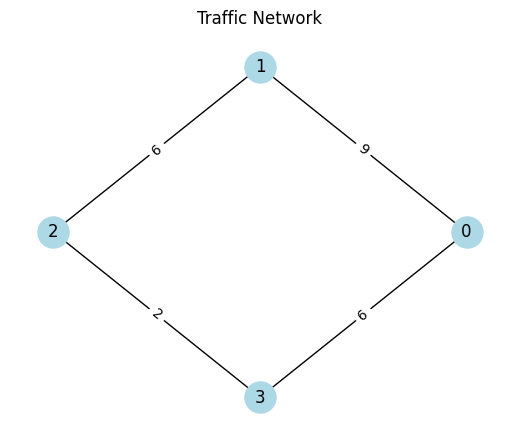


True optimal balanced cut weight = 23.0
Optimal partition(s): ['0101', '1010']

Using penalty λ = 92.00
Searching for optimal QAOA parameters...
Best parameters found: γ = 2.917, β = 1.571 (reps=5)
Probability of optimal partition(s) = 0.5382

Top 8 partitions (bitstring, probability):
  0101 : 0.2691
  1010 : 0.2691
  0001 : 0.0564
  0010 : 0.0564
  1101 : 0.0564
  1110 : 0.0564
  0000 : 0.0390
  1111 : 0.0390

Corresponding cut weights:
  0101 : cut = 23.0
  1010 : cut = 23.0
  0001 : cut = 8.0
  0010 : cut = 8.0
  1101 : cut = 8.0
  1110 : cut = 8.0
  0000 : cut = 0.0
  1111 : cut = 0.0


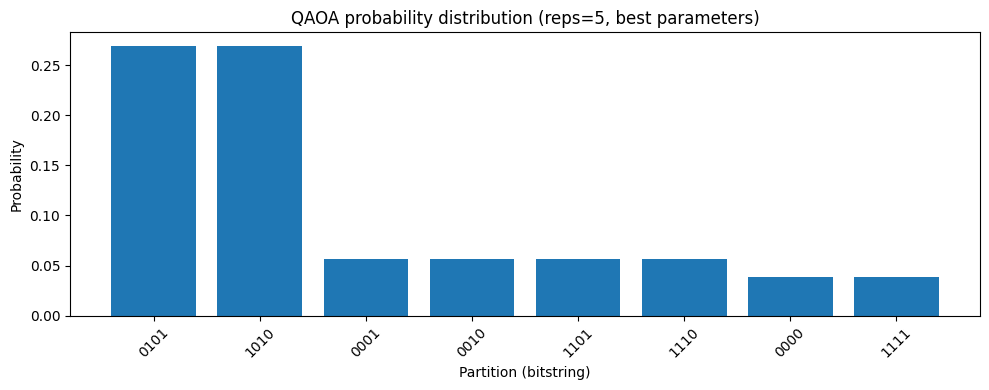

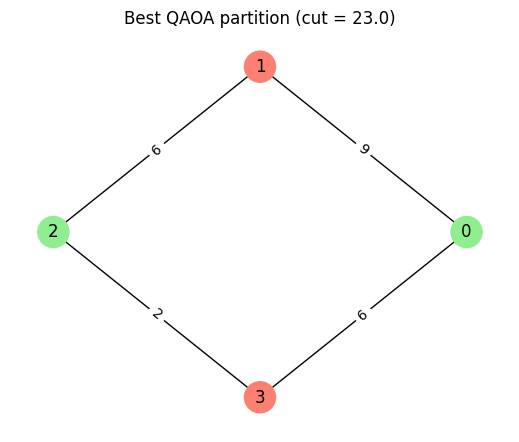

In [152]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from itertools import product

from qiskit.primitives import StatevectorSampler
from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.primitives import PrimitiveResult
from qiskit_algorithms.utils import algorithm_globals

algorithm_globals.random_seed = 42

# ------------------------------------------------------------
# 1. Define your traffic graph (replace with your own edges)
# ------------------------------------------------------------
n = 4   # must be even
edge_list = [(0,1,9), (1,2,6), (2,3,2), (3,0,6)]  # equal weights

# Build weight matrix
weights = np.zeros((n, n))
for u, v, w in edge_list:
    weights[u, v] = w
    weights[v, u] = w

# Build graph for visualisation
G = nx.Graph()
G.add_weighted_edges_from(edge_list)
pos = nx.circular_layout(G)

print("Your traffic network:")
plt.figure(figsize=(5,4))
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=500)
edge_labels = {(u,v): f"{w}" for u,v,w in edge_list}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title("Traffic Network")
plt.show()

# ------------------------------------------------------------
# 2. Brute force to find the true optimal balanced partition
# ------------------------------------------------------------
def cut_weight(bits_str, weights):
    x = [int(b) for b in bits_str]
    cut = 0.0
    for i in range(n):
        for j in range(i+1, n):
            if x[i] != x[j]:
                cut += weights[i, j]
    return cut

best_cut = -1
best_partitions = []
for bits in product('01', repeat=n):
    if bits.count('1') == n//2:
        bits_str = ''.join(bits)
        cut = cut_weight(bits_str, weights)
        if cut > best_cut:
            best_cut = cut
            best_partitions = [bits_str]
        elif cut == best_cut:
            best_partitions.append(bits_str)

print(f"\nTrue optimal balanced cut weight = {best_cut}")
print(f"Optimal partition(s): {best_partitions}")

# ------------------------------------------------------------
# 3. Build the exact Ising Hamiltonian
# ------------------------------------------------------------
def balanced_maxcut_hamiltonian(weights, lambda_penalty):
    n = weights.shape[0]
    H = SparsePauliOp(['I'*n], coeffs=[0.0])
    # MaxCut term: -½ Σ w_ij (1 - Z_i Z_j) → -½ w_ij Z_i Z_j
    for i in range(n):
        for j in range(i+1, n):
            w = weights[i, j]
            if w == 0:
                continue
            pauli = ['I']*n
            pauli[i] = 'Z'
            pauli[j] = 'Z'
            H += SparsePauliOp(''.join(pauli), coeffs=[-0.5 * w])
    # Penalty: λ (Σ Z_i)^2 = 2λ Σ_{i<j} Z_i Z_j + constant
    for i in range(n):
        for j in range(i+1, n):
            pauli = ['I']*n
            pauli[i] = 'Z'
            pauli[j] = 'Z'
            H += SparsePauliOp(''.join(pauli), coeffs=[2 * lambda_penalty])
    return H

total_weight = np.sum(weights) / 2
lambda_penalty = total_weight * n
print(f"\nUsing penalty λ = {lambda_penalty:.2f}")

H = balanced_maxcut_hamiltonian(weights, lambda_penalty)

# ------------------------------------------------------------
# 4. Grid search over QAOA parameters using statevector simulation
# ------------------------------------------------------------
reps = 5
ansatz = QAOAAnsatz(H, reps=reps)   # no measurements needed

# Grid over γ ∈ [0, π] and β ∈ [0, π]
gammas = np.linspace(0, np.pi, 15)
betas = np.linspace(0, np.pi, 15)

best_prob = 0
best_params = None

print("Searching for optimal QAOA parameters...")
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

for gamma in gammas:
    for beta in betas:
        params = np.array([gamma, beta] * reps)
        # Bind parameters to the ansatz
        bound_circuit = ansatz.assign_parameters(params)
        # Get final statevector (simulate without measurements)
        sv = Statevector(bound_circuit)
        # Compute probability of any optimal partition
        prob = 0
        for bits_str in best_partitions:
            # Convert bitstring to integer (big-endian: bit0 = most significant)
            idx = int(bits_str, 2)
            prob += np.abs(sv[idx])**2
        if prob > best_prob:
            best_prob = prob
            best_params = params

print(f"Best parameters found: γ = {best_params[0]:.3f}, β = {best_params[1]:.3f} (reps={reps})")
print(f"Probability of optimal partition(s) = {best_prob:.4f}")

# ------------------------------------------------------------
# 5. Final probability distribution using best parameters
# ------------------------------------------------------------
final_circuit = ansatz.assign_parameters(best_params)
final_sv = Statevector(final_circuit)
probabilities = {}
for i, amp in enumerate(final_sv):
    bits = format(i, f'0{n}b')
    probabilities[bits] = np.abs(amp)**2

sorted_probs = sorted(probabilities.items(), key=lambda x: x[1], reverse=True)

print("\nTop 8 partitions (bitstring, probability):")
for bits, p in sorted_probs[:8]:
    print(f"  {bits} : {p:.4f}")

print("\nCorresponding cut weights:")
for bits, p in sorted_probs[:8]:
    cut = cut_weight(bits, weights)
    print(f"  {bits} : cut = {cut}")

# ------------------------------------------------------------
# 6. Plot probability distribution
# ------------------------------------------------------------
top_n = 8
top_bits = [b for b,_ in sorted_probs[:top_n]]
top_probs = [p for _,p in sorted_probs[:top_n]]

plt.figure(figsize=(10,4))
plt.bar(range(top_n), top_probs, tick_label=top_bits)
plt.xlabel("Partition (bitstring)")
plt.ylabel("Probability")
plt.title(f"QAOA probability distribution (reps={reps}, best parameters)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Visualise the best partition
# ------------------------------------------------------------
best_bits = sorted_probs[0][0]
node_colors = ['lightgreen' if best_bits[i]=='0' else 'salmon' for i in range(n)]
plt.figure(figsize=(5,4))
nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=500)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title(f"Best QAOA partition (cut = {cut_weight(best_bits, weights)})")
plt.show()

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from itertools import product

from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit_algorithms.optimizers import COBYLA

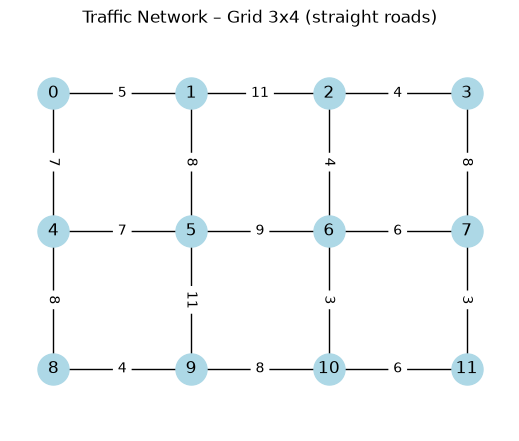

Optimal cut weight = 112.0
Optimal partitions: ['010110100101', '101001011010']
Using penalty λ = 1120.00
Step 1: Coarse grid search...


p:\Projects\TFD_SYK_HAMILTONIAN\qiskit_env\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve


MemoryError: 

In [10]:

# ------------------------------------------------------------
# 1. Build a grid road network (straight roads, rows x columns)
# ------------------------------------------------------------
rows = 3       # number of rows
cols = 4       # number of columns (total nodes = rows*cols, must be even)
n = rows * cols

# Generate all edges: horizontal (within rows) and vertical (within columns)
edge_list = []
# Horizontal edges
for r in range(rows):
    for c in range(cols - 1):
        u = r * cols + c
        v = r * cols + (c + 1)
        w = np.random.randint(3, 12)   # random traffic weight (3-11)
        edge_list.append((u, v, w))
# Vertical edges
for c in range(cols):
    for r in range(rows - 1):
        u = r * cols + c
        v = (r + 1) * cols + c
        w = np.random.randint(3, 12)
        edge_list.append((u, v, w))

# Build weight matrix
weights = np.zeros((n, n))
for u, v, w in edge_list:
    weights[u, v] = w
    weights[v, u] = w

# Build graph for visualisation
G = nx.Graph()
G.add_weighted_edges_from(edge_list)
# Position nodes in a grid layout (straight roads)
pos = {}
for r in range(rows):
    for c in range(cols):
        node = r * cols + c
        pos[node] = (c, -r)   # straight line layout

plt.figure(figsize=(5,4))
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=500)
edge_labels = {(u, v): f"{w}" for u, v, w in edge_list}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title(f"Traffic Network – Grid {rows}x{cols} (straight roads)")
plt.axis('equal')
plt.show()

# ------------------------------------------------------------
# 2. Brute force optimal partitions (same as before)
# ------------------------------------------------------------
def cut_weight(bits_str, weights):
    x = [int(b) for b in bits_str]
    cut = 0.0
    for i in range(n):
        for j in range(i+1, n):
            if x[i] != x[j]:
                cut += weights[i,j]
    return cut

best_cut = -1
best_partitions = []
for bits in product('01', repeat=n):
    if bits.count('1') == n//2:
        bits_str = ''.join(bits)
        cut = cut_weight(bits_str, weights)
        if cut > best_cut:
            best_cut = cut
            best_partitions = [bits_str]
        elif cut == best_cut:
            best_partitions.append(bits_str)

print(f"Optimal cut weight = {best_cut}")
print(f"Optimal partitions: {best_partitions}")

# ------------------------------------------------------------
# 3. Build Hamiltonian with stronger penalty (same)
# ------------------------------------------------------------
def balanced_maxcut_hamiltonian(weights, lambda_penalty):
    n = weights.shape[0]
    H = SparsePauliOp(['I'*n], coeffs=[0.0])
    for i in range(n):
        for j in range(i+1, n):
            w = weights[i,j]
            if w == 0: continue
            pauli = ['I']*n
            pauli[i] = 'Z'
            pauli[j] = 'Z'
            H += SparsePauliOp(''.join(pauli), coeffs=[-0.5 * w])
    for i in range(n):
        for j in range(i+1, n):
            pauli = ['I']*n
            pauli[i] = 'Z'
            pauli[j] = 'Z'
            H += SparsePauliOp(''.join(pauli), coeffs=[2 * lambda_penalty])
    return H

total_weight = np.sum(weights) / 2
lambda_penalty = 10 * total_weight
print(f"Using penalty λ = {lambda_penalty:.2f}")

H = balanced_maxcut_hamiltonian(weights, lambda_penalty)

# ------------------------------------------------------------
# 4. QAOA with higher reps and 2‑step optimisation (same)
# ------------------------------------------------------------
reps = 3
ansatz = QAOAAnsatz(H, reps=reps)

gammas = np.linspace(0, np.pi, 25)
betas = np.linspace(0, np.pi, 25)

best_prob = 0
best_params = None

print("Step 1: Coarse grid search...")
for gamma in gammas:
    for beta in betas:
        params = np.array([gamma, beta] * reps)
        bound_circuit = ansatz.assign_parameters(params)
        sv = Statevector(bound_circuit)
        prob = 0
        for bits_str in best_partitions:
            idx = int(bits_str, 2)
            prob += np.abs(sv[idx])**2
        if prob > best_prob:
            best_prob = prob
            best_params = params

print(f"  Best coarse probability = {best_prob:.4f}")

def objective(params):
    bound_circuit = ansatz.assign_parameters(params)
    sv = Statevector(bound_circuit)
    prob = 0
    for bits_str in best_partitions:
        idx = int(bits_str, 2)
        prob += np.abs(sv[idx])**2
    return -prob

optimizer = COBYLA(maxiter=200, tol=1e-5)
res = optimizer.minimize(objective, best_params)
final_params = res.x
final_prob = -res.fun
print(f"Step 2: After local optimisation, probability = {final_prob:.4f}")

# ------------------------------------------------------------
# 5. Final probability distribution (same)
# ------------------------------------------------------------
final_circuit = ansatz.assign_parameters(final_params)
final_sv = Statevector(final_circuit)
probs = {format(i, f'0{n}b'): np.abs(amp)**2 for i, amp in enumerate(final_sv)}
sorted_probs = sorted(probs.items(), key=lambda x: x[1], reverse=True)

print("\nTop 8 partitions (bitstring, probability):")
for bits, p in sorted_probs[:8]:
    print(f"  {bits} : {p:.4f}")

# ------------------------------------------------------------
# 6. Plot (same)
# ------------------------------------------------------------
top_n = 8
top_bits = [b for b,_ in sorted_probs[:top_n]]
top_probs = [p for _,p in sorted_probs[:top_n]]

plt.figure(figsize=(10,4))
plt.bar(range(top_n), top_probs, tick_label=top_bits)
plt.xlabel("Partition (bitstring)")
plt.ylabel("Probability")
plt.title(f"QAOA probability distribution (reps={reps}, final probability {final_prob:.3f})")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualise best partition
best_bits = sorted_probs[0][0]
node_colors = ['lightgreen' if best_bits[i]=='0' else 'salmon' for i in range(n)]
plt.figure(figsize=(5,4))
nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=500)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title(f"Best QAOA partition (cut = {cut_weight(best_bits, weights)})")
plt.axis('equal')
plt.show()

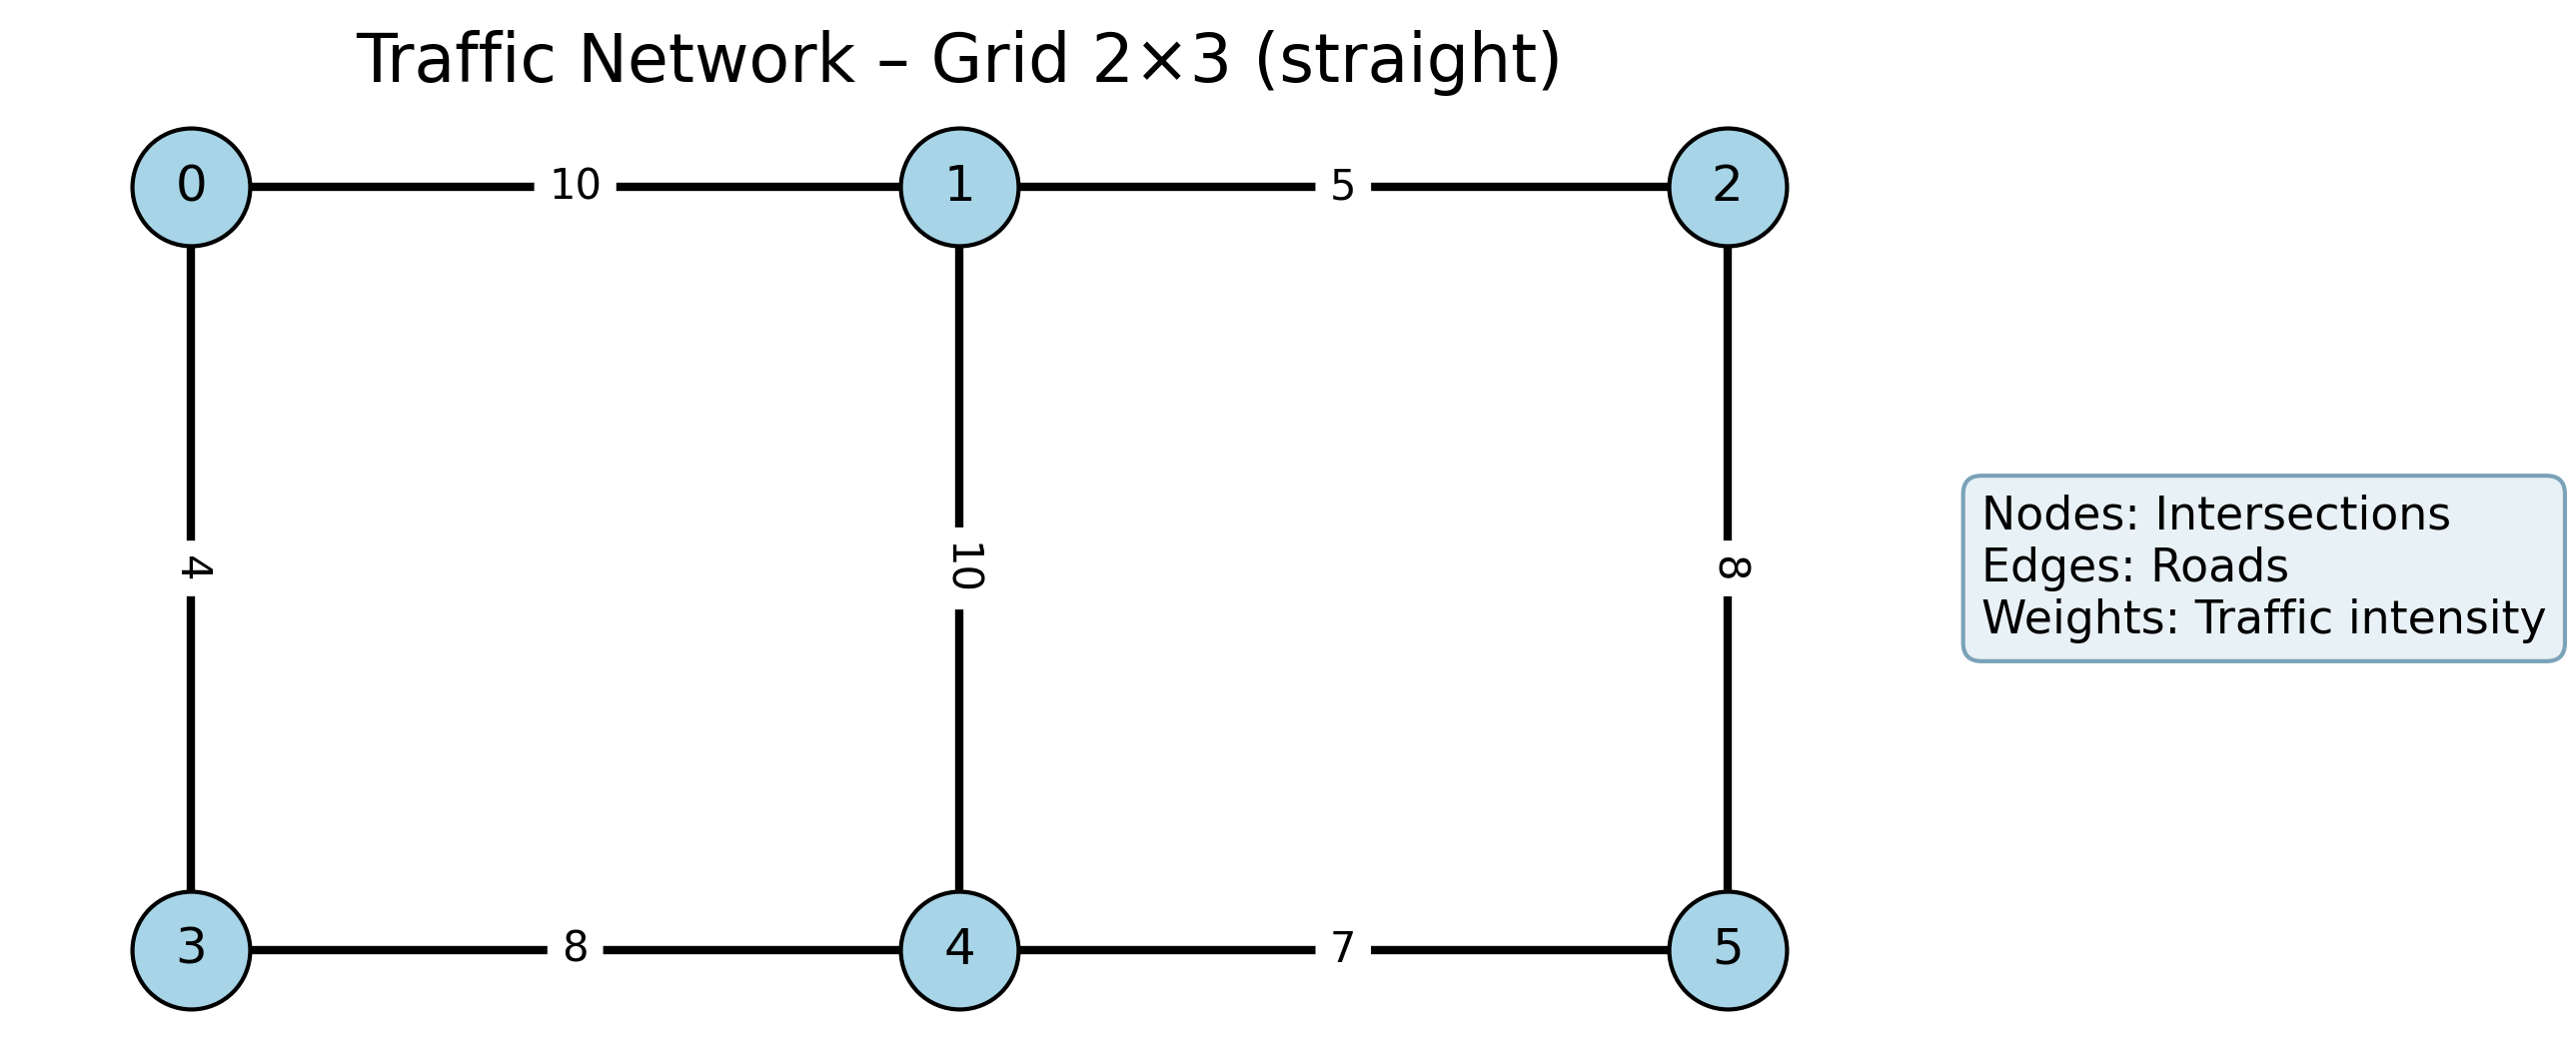

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graph
G = nx.Graph()

# Add nodes
G.add_nodes_from([0, 1, 2, 3, 4, 5])

# Add weighted edges
edges = [
    (0, 1, 10),
    (1, 2, 5),
    (0, 3, 4),
    (1, 4, 10),
    (2, 5, 8),
    (3, 4, 8),
    (4, 5, 7)
]
G.add_weighted_edges_from(edges)

# Custom positions for 2x3 grid shape
pos = {
    0: (0, 1),
    1: (1, 1),
    2: (2, 1),
    3: (0, 0),
    4: (1, 0),
    5: (2, 0)
}

plt.figure(figsize=(8, 4), dpi=300)

# Draw nodes and edges
nx.draw_networkx_nodes(G, pos, node_size=800, node_color="#a7d4e6", edgecolors="black")
nx.draw_networkx_edges(G, pos, width=2, edge_color="black")

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=12)

# Edge weight labels
edge_labels = {(u, v): w for u, v, w in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

# Title
plt.title("Traffic Network – Grid 2×3 (straight)", fontsize=16)

# Add information block
text = (
    "Nodes: Intersections\n"
    "Edges: Roads\n"
    "Weights: Traffic intensity"
)

plt.gca().text(
    1.05, 0.5, text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='center',
    bbox=dict(boxstyle="round,pad=0.4", fc="#e8f1f5", ec="#7aa2b8")
)

plt.axis("off")

# Save as TIFF
plt.savefig("traffic_network.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()


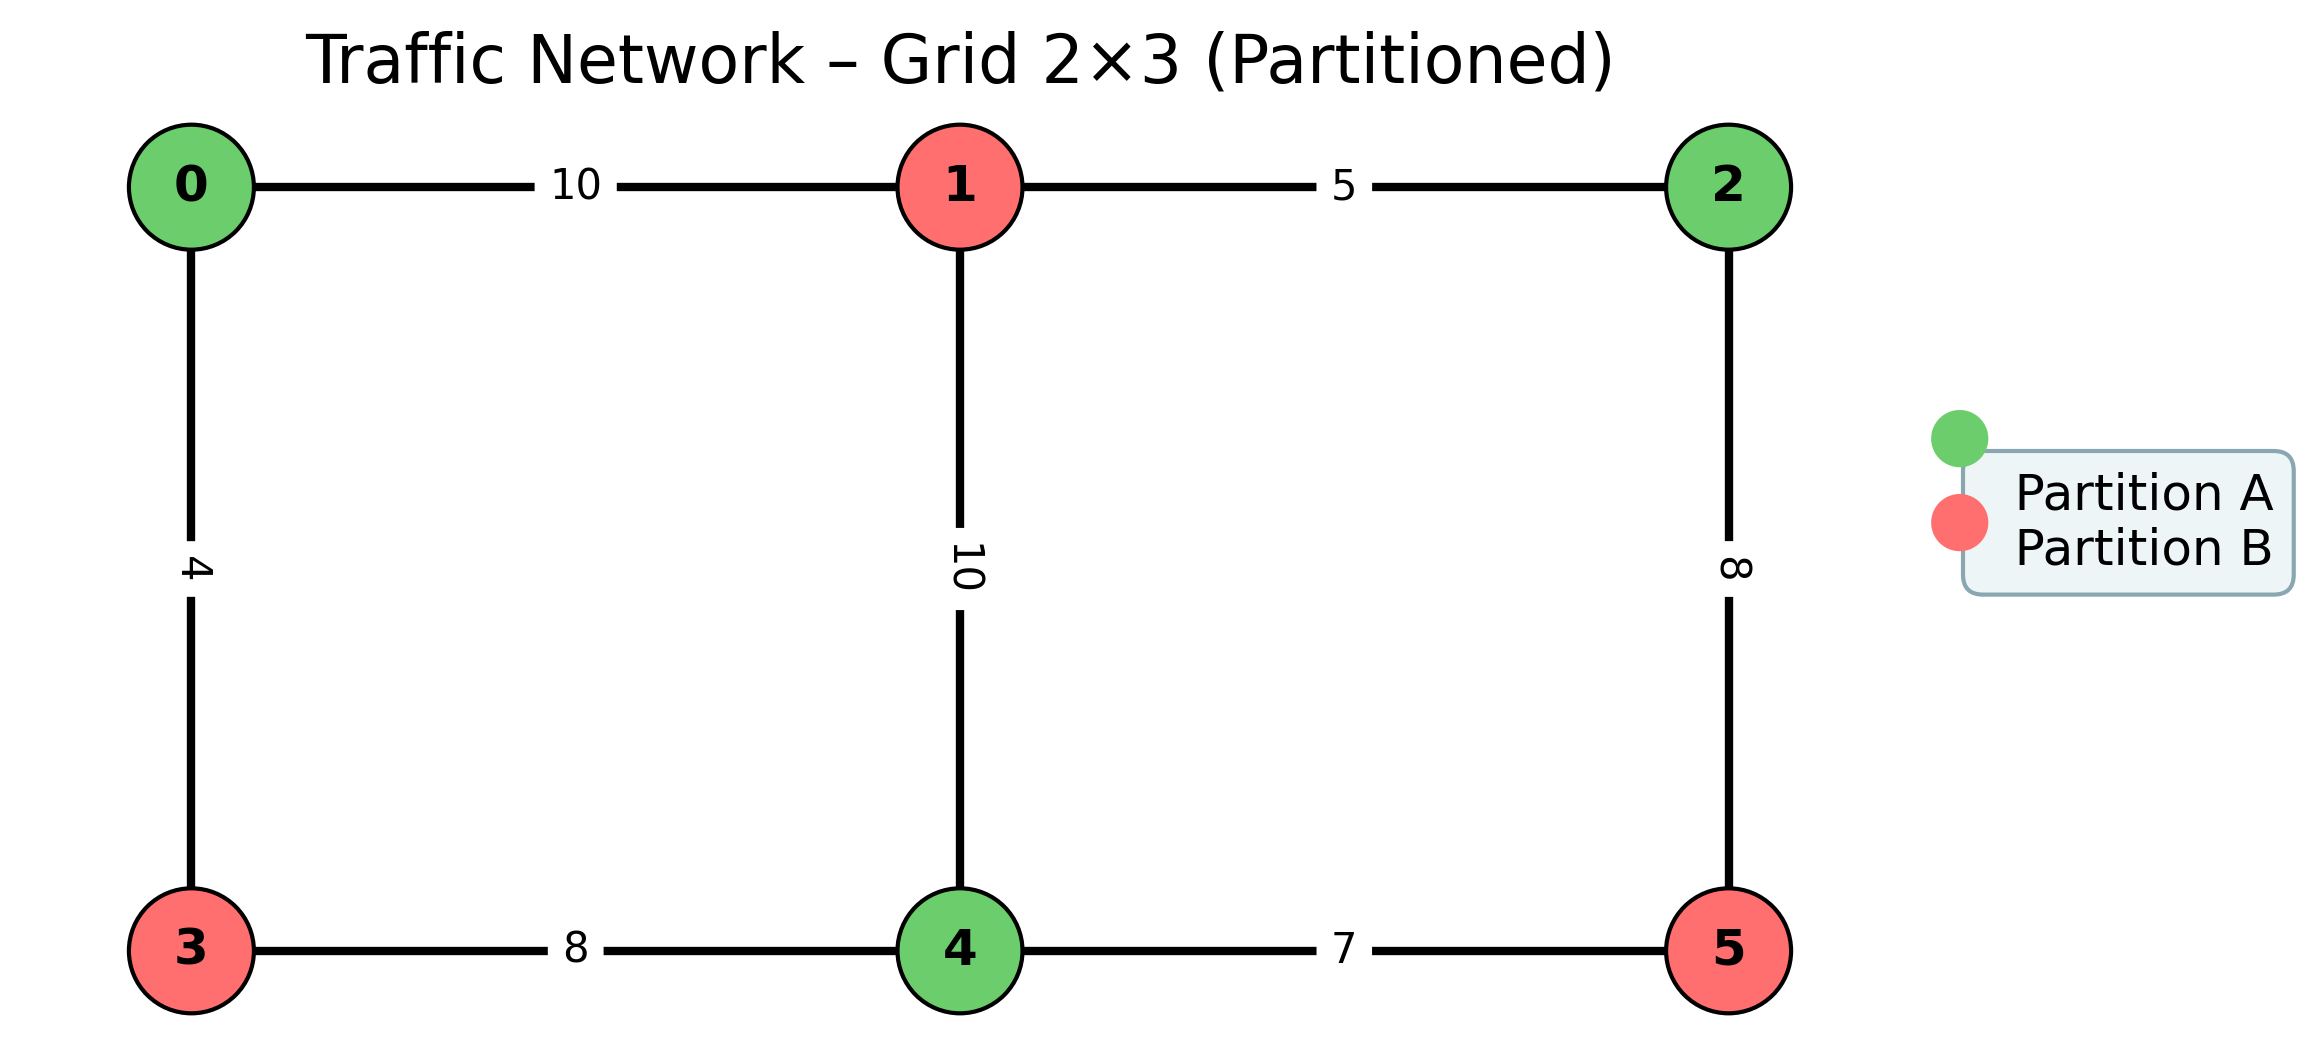

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graph
G = nx.Graph()

# Add nodes
G.add_nodes_from([0, 1, 2, 3, 4, 5])

# Add weighted edges
edges = [
    (0, 1, 10),
    (1, 2, 5),
    (0, 3, 4),
    (1, 4, 10),
    (2, 5, 8),
    (3, 4, 8),
    (4, 5, 7)
]
G.add_weighted_edges_from(edges)

# Positions in a 2x3 grid
pos = {
    0: (0, 1),
    1: (1, 1),
    2: (2, 1),
    3: (0, 0),
    4: (1, 0),
    5: (2, 0)
}

# Partition assignment (example: matching your image)
partition_A = [0, 2, 4]
partition_B = [1, 3, 5]

node_colors = []
for n in G.nodes():
    if n in partition_A:
        node_colors.append("#6ccd6c")  # light green/blue-ish for A
    else:
        node_colors.append("#ff6f6f")  # light red for B

plt.figure(figsize=(8, 4), dpi=300)

# Draw nodes & edges
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=900, edgecolors="black")
nx.draw_networkx_edges(G, pos, width=2)

# Labels
nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold")

# Edge weight labels
edge_labels = {(u, v): w for u, v, w in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

# Title
plt.title("Traffic Network – Grid 2×3 (Partitioned)", fontsize=16)

# Legend-like box
legend_text = (
    "● Partition A\n"
    "● Partition B"
)

# Draw box with matching colors
plt.gca().text(
    1.05, 0.55,
    "  Partition A\n  Partition B",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='center',
    bbox=dict(boxstyle="round,pad=0.4", fc="#eef5f7", ec="#8aa7b1")
)

# Colored circles beside text
plt.gca().text(1.02, 0.62, "●", color="#6ccd6c", transform=plt.gca().transAxes, fontsize=18)
plt.gca().text(1.02, 0.53, "●", color="#ff6f6f", transform=plt.gca().transAxes, fontsize=18)

plt.axis("off")

# Save as TIFF
plt.savefig("traffic_network_partitioned.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()


In [7]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from itertools import product
from scipy.optimize import minimize

from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp, Statevector

# ============================================================
# RANDOM SEED
# ============================================================
np.random.seed(42)

# ============================================================
# 1. BUILD TRAFFIC NETWORK (2x3 grid)
# ============================================================
rows, cols = 2, 3
n = rows * cols

edge_list = []
# horizontal
for r in range(rows):
    for c in range(cols - 1):
        u = r * cols + c
        v = r * cols + (c + 1)
        w = np.random.randint(3, 12)
        edge_list.append((u, v, w))
# vertical
for c in range(cols):
    for r in range(rows - 1):
        u = r * cols + c
        v = (r + 1) * cols + c
        w = np.random.randint(3, 12)
        edge_list.append((u, v, w))

weights = np.zeros((n, n))
for u, v, w in edge_list:
    weights[u, v] = w
    weights[v, u] = w

G = nx.Graph()
G.add_weighted_edges_from(edge_list)
pos = {r * cols + c: (c, -r) for r in range(rows) for c in range(cols)}

# ============================================================
# 2. BRUTE FORCE OPTIMAL BALANCED CUT
# ============================================================
def cut_value(bitstring, wmat):
    x = [int(b) for b in bitstring]
    cut = 0.0
    for i in range(n):
        for j in range(i + 1, n):
            if x[i] != x[j]:
                cut += wmat[i, j]
    return cut

best_cut = -1.0
best_partitions = []
for bits in product('01', repeat=n):
    if bits.count('1') == n // 2:
        bs = ''.join(bits)
        cur = cut_value(bs, weights)
        if cur > best_cut:
            best_cut = cur
            best_partitions = [bs]
        elif cur == best_cut:
            best_partitions.append(bs)

print("\n=== OPTIMAL BALANCED MAXCUT ===")
print(f"Optimal cut = {best_cut}")
print(f"Example optimal partition: {best_partitions[0]}\n")

# ============================================================
# 3. CORRECT HAMILTONIAN FOR BALANCED MAXCUT
# ============================================================
def build_hamiltonian(wmat, lambda_penalty):
    """
    H_total = H_cost + λ * H_balance
    H_cost = Σ_{i<j} w_ij Z_i Z_j   (to be minimized → cut maximized)
    H_balance = Σ_{i<j} Z_i Z_j     (penalises unbalanced states)
    """
    nq = wmat.shape[0]
    H = SparsePauliOp(['I' * nq], coeffs=[0.0])

    # Cost term: + w_ij * Z_i Z_j
    for i in range(nq):
        for j in range(i + 1, nq):
            w = wmat[i, j]
            if w != 0:
                pauli = ['I'] * nq
                pauli[i] = 'Z'
                pauli[j] = 'Z'
                H += SparsePauliOp(''.join(pauli), coeffs=[w])

    # Balance penalty: + λ * Z_i Z_j  for all i<j
    for i in range(nq):
        for j in range(i + 1, nq):
            pauli = ['I'] * nq
            pauli[i] = 'Z'
            pauli[j] = 'Z'
            H += SparsePauliOp(''.join(pauli), coeffs=[lambda_penalty])

    return H

# ============================================================
# 4. FIND OPTIMAL λ SO THAT GROUND STATES ARE BALANCED
# ============================================================
def is_balanced(bitstring):
    return bitstring.count('1') == n // 2

def find_optimal_lambda():
    """Smallest λ such that all ground states of H_total are balanced."""
    candidates = np.linspace(0, 20, 41)
    all_states = [format(i, f'0{n}b') for i in range(2**n)]
    # Precompute cut and sum of Z_iZ_j for every state
    sum_zz = {}
    for bs in all_states:
        s = 0
        bits = [1 if b == '1' else -1 for b in bs]   # +1 for 0, -1 for 1? Z_i|0>=+|0>, Z_i|1>=-|1>
        # Actually canonical: bit '0' -> eigenvalue +1, bit '1' -> eigenvalue -1.
        # Then Z_iZ_j = (+1 if bits same, -1 if different).
        # We'll compute sum_{i<j} Z_iZ_j directly.
        total = 0
        for i in range(n):
            for j in range(i+1, n):
                total += (1 if bits[i] == bits[j] else -1)
        sum_zz[bs] = total

    for lam in candidates:
        energies = {}
        for bs in all_states:
            # H_cost expectation = Σ w_ij * <Z_iZ_j> = Σ w_ij * (1 if same, -1 if diff)
            cost = 0.0
            for i in range(n):
                for j in range(i+1, n):
                    w = weights[i, j]
                    if w != 0:
                        zz = 1 if (bs[i] == bs[j]) else -1
                        cost += w * zz
            # total energy
            energy = cost + lam * sum_zz[bs]
            energies[bs] = energy
        min_energy = min(energies.values())
        ground_states = [bs for bs, e in energies.items() if abs(e - min_energy) < 1e-6]
        if all(is_balanced(bs) for bs in ground_states):
            return lam
    return 20.0

lambda_penalty = find_optimal_lambda()
print(f"Optimal penalty λ = {lambda_penalty:.2f}")

H_total = build_hamiltonian(weights, lambda_penalty)

# ============================================================
# 5. QAOA HELPER FUNCTIONS
# ============================================================
def expected_cut_from_probs(probs, wmat):
    exp = 0.0
    for bs, p in probs.items():
        exp += p * cut_value(bs, wmat)
    return exp

def objective_total(params, ansatz, H):
    circ = ansatz.assign_parameters(params)
    sv = Statevector(circ)
    return sv.expectation_value(H).real   # minimize this

# Store best parameters for warm‑start
best_params_for_p = {}

# ============================================================
# 6. MAIN LOOP OVER p
# ============================================================
max_p = 5
p_values = []
approx_ratios = []
expected_cuts = []
convergence_histories = {}

for p in range(1, max_p + 1):
    print(f"\n=== QAOA Depth p = {p} ===")
    ansatz = QAOAAnsatz(H_total, reps=p)

    # --- Warm‑start initial parameters ---
    if p == 1:
        # Heuristic: linear ramp 0..π/2 for γ, 0..π for β
        gammas = np.linspace(0, np.pi/2, 1)
        betas  = np.linspace(0, np.pi, 1)
        init_params = np.array([gammas[0], betas[0]])
        init_params += np.random.normal(0, 0.05, size=2)
    else:
        prev = best_params_for_p[p-1]          # length 2*(p-1)
        # New layer angles: small random around heuristic
        gamma_new = np.random.uniform(0, np.pi/2)
        beta_new  = np.random.uniform(0, np.pi)
        init_params = np.concatenate([prev, [gamma_new, beta_new]])

    # --- Optimization with convergence tracking ---
    history = []   # total energy values during optimization

    def callback(xk):
        val = objective_total(xk, ansatz, H_total)
        history.append(val)

    result = minimize(
        lambda x: objective_total(x, ansatz, H_total),
        init_params,
        method='L-BFGS-B',
        callback=callback,
        options={'maxiter': 200, 'ftol': 1e-6}
    )
    optimal_params = result.x
    best_params_for_p[p] = optimal_params
    convergence_histories[p] = history

    # --- Final evaluation ---
    final_circ = ansatz.assign_parameters(optimal_params)
    sv = Statevector(final_circ)
    probs = {format(i, f'0{n}b'): np.abs(sv[i])**2 for i in range(2**n)}
    exp_cut = expected_cut_from_probs(probs, weights)
    ratio = exp_cut / best_cut

    p_values.append(p)
    expected_cuts.append(exp_cut)
    approx_ratios.append(ratio)

    print(f"Expected cut = {exp_cut:.4f}  |  Approximation ratio = {ratio:.4f}")

    # --- Plot probability distribution (top 8) ---
    sorted_probs = sorted(probs.items(), key=lambda x: x[1], reverse=True)[:8]
    top_bits = [b for b, _ in sorted_probs]
    top_probs_vals = [pr for _, pr in sorted_probs]
    plt.figure(figsize=(10, 4))
    plt.bar(range(len(top_bits)), top_probs_vals, tick_label=top_bits)
    plt.xlabel("Partition (bitstring)")
    plt.ylabel("Probability")
    plt.title(f"Probability Distribution (p={p})")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"probability_distribution_p_{p}.tiff", format='tiff', dpi=600)
    plt.close()

    # --- Plot convergence of total energy ---
    plt.figure(figsize=(8, 5))
    plt.plot(history, marker='o', markersize=3, linewidth=1)
    plt.xlabel("Iteration (function evaluation)")
    plt.ylabel(r"$\langle H_{\text{total}} \rangle$")
    plt.title(f"Convergence of QAOA (p={p})")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"convergence_p_{p}.tiff", format='tiff', dpi=600)
    plt.close()

# ============================================================
# 7. PLOT APPROXIMATION RATIO vs p
# ============================================================
plt.figure(figsize=(7, 5))
plt.plot(p_values, approx_ratios, marker='o', linewidth=2)
plt.xlabel("QAOA Layers (p)")
plt.ylabel("Approximation Ratio")
plt.title("Approximation Ratio vs QAOA Depth (with warm‑start)")
plt.grid(True)
plt.savefig("approximation_ratio_vs_p.tiff", format='tiff', dpi=600)
plt.close()

# ============================================================
# 8. BEST PARTITION VISUALISATION
# ============================================================
# Use the best parameters from the largest p
final_circ_best = QAOAAnsatz(H_total, reps=max_p).assign_parameters(best_params_for_p[max_p])
sv_best = Statevector(final_circ_best)
probs_best = {format(i, f'0{n}b'): np.abs(sv_best[i])**2 for i in range(2**n)}
best_bs = max(probs_best.items(), key=lambda x: x[1])[0]
best_cut_found = cut_value(best_bs, weights)

node_colors = ['lightgreen' if best_bs[i] == '0' else 'salmon' for i in range(n)]
plt.figure(figsize=(6, 4))
nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=700)
edge_labels = {(u, v): w for u, v, w in edge_list}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title(f"Best QAOA Partition (p={max_p})\nCut = {best_cut_found} (optimal {best_cut})")
plt.axis('equal')
plt.savefig("best_partition.tiff", format='tiff', dpi=600)
plt.close()

# ============================================================
# 9. TRAFFIC NETWORK PLOT
# ============================================================
plt.figure(figsize=(6, 4))
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=700)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title("Traffic Road Network")
plt.axis('equal')
plt.savefig("traffic_network.tiff", format='tiff', dpi=600)
plt.close()

# ============================================================
# 10. SUMMARY
# ============================================================
print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
for i, p in enumerate(p_values):
    print(f"p={p:2d} : Expected Cut = {expected_cuts[i]:6.2f}  |  Approx. Ratio = {approx_ratios[i]:.4f}")
print(f"\nOptimal penalty λ = {lambda_penalty:.2f}")
print("All TIFF plots saved successfully.")


=== OPTIMAL BALANCED MAXCUT ===
Optimal cut = 55.0
Example optimal partition: 010101

Optimal penalty λ = 0.00

=== QAOA Depth p = 1 ===
Expected cut = 28.8022  |  Approximation ratio = 0.5237

=== QAOA Depth p = 2 ===
Expected cut = 34.2224  |  Approximation ratio = 0.6222

=== QAOA Depth p = 3 ===
Expected cut = 36.3374  |  Approximation ratio = 0.6607

=== QAOA Depth p = 4 ===
Expected cut = 40.2619  |  Approximation ratio = 0.7320

=== QAOA Depth p = 5 ===
Expected cut = 45.8776  |  Approximation ratio = 0.8341

FINAL RESULTS
p= 1 : Expected Cut =  28.80  |  Approx. Ratio = 0.5237
p= 2 : Expected Cut =  34.22  |  Approx. Ratio = 0.6222
p= 3 : Expected Cut =  36.34  |  Approx. Ratio = 0.6607
p= 4 : Expected Cut =  40.26  |  Approx. Ratio = 0.7320
p= 5 : Expected Cut =  45.88  |  Approx. Ratio = 0.8341

Optimal penalty λ = 0.00
All TIFF plots saved successfully.


In [8]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from itertools import product
from scipy.optimize import minimize

from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp, Statevector

np.random.seed(42)

# ------------------------------------------------------------
# 1. Build a graph (2x3 grid) – bipartite, so λ will be 0
# ------------------------------------------------------------
rows, cols = 2, 3
n = rows * cols
edge_list = []
for r in range(rows):
    for c in range(cols - 1):
        u, v = r * cols + c, r * cols + c + 1
        w = np.random.randint(3, 12)
        edge_list.append((u, v, w))
for c in range(cols):
    for r in range(rows - 1):
        u, v = r * cols + c, (r + 1) * cols + c
        w = np.random.randint(3, 12)
        edge_list.append((u, v, w))

weights = np.zeros((n, n))
for u, v, w in edge_list:
    weights[u, v] = w
    weights[v, u] = w

# Graph for drawing
G = nx.Graph()
G.add_weighted_edges_from(edge_list)
pos = {r * cols + c: (c, -r) for r in range(rows) for c in range(cols)}

# ------------------------------------------------------------
# 2. Brute force optimal balanced cut
# ------------------------------------------------------------
def cut_value(bs, wmat):
    x = [int(b) for b in bs]
    cut = 0.0
    for i in range(n):
        for j in range(i+1, n):
            if x[i] != x[j]:
                cut += wmat[i, j]
    return cut

best_cut = -1.0
best_parts = []
for bits in product('01', repeat=n):
    if bits.count('1') == n//2:
        bs = ''.join(bits)
        cur = cut_value(bs, weights)
        if cur > best_cut:
            best_cut = cur
            best_parts = [bs]
        elif cur == best_cut:
            best_parts.append(bs)

print("\n=== OPTIMAL BALANCED CUT ===")
print(f"Optimal cut = {best_cut}")
print(f"Example: {best_parts[0]}\n")

# ------------------------------------------------------------
# 3. Build Hamiltonian (cost + penalty)
# ------------------------------------------------------------
def build_hamiltonian(wmat, lam):
    nq = wmat.shape[0]
    H = SparsePauliOp(['I'*nq], coeffs=[0.0])
    # Cost term: + w_ij Z_i Z_j   (minimising this maximises the cut)
    for i in range(nq):
        for j in range(i+1, nq):
            w = wmat[i, j]
            if w != 0:
                pauli = ['I']*nq
                pauli[i] = 'Z'
                pauli[j] = 'Z'
                H += SparsePauliOp(''.join(pauli), coeffs=[w])
    # Penalty term: + λ * Z_i Z_j  for all i<j
    for i in range(nq):
        for j in range(i+1, nq):
            pauli = ['I']*nq
            pauli[i] = 'Z'
            pauli[j] = 'Z'
            H += SparsePauliOp(''.join(pauli), coeffs=[lam])
    return H

# ------------------------------------------------------------
# 4. Find smallest λ that forces all ground states to be balanced
# ------------------------------------------------------------
def is_balanced(bs):
    return bs.count('1') == n//2

def find_optimal_lambda():
    all_states = [format(i, f'0{n}b') for i in range(2**n)]
    # Precompute sum_{i<j} Z_i Z_j for each state
    sum_zz = {}
    for bs in all_states:
        s = 0
        for i in range(n):
            for j in range(i+1, n):
                s += 1 if bs[i] == bs[j] else -1
        sum_zz[bs] = s

    for lam in np.linspace(0, 20, 41):   # 0, 0.5, ..., 20
        energies = {}
        for bs in all_states:
            # <H_cost> = Σ w_ij * (1 if same, -1 if different)
            cost = 0.0
            for i in range(n):
                for j in range(i+1, n):
                    if weights[i, j] != 0:
                        zz = 1 if bs[i] == bs[j] else -1
                        cost += weights[i, j] * zz
            energy = cost + lam * sum_zz[bs]
            energies[bs] = energy
        min_e = min(energies.values())
        ground = [bs for bs, e in energies.items() if abs(e - min_e) < 1e-6]
        if all(is_balanced(bs) for bs in ground):
            return lam
    return 20.0

lambda_penalty = find_optimal_lambda()
print(f"Optimal penalty λ = {lambda_penalty:.2f}")
if lambda_penalty == 0:
    print("(Graph is bipartite with equal partition sizes – no penalty needed.)")
H_total = build_hamiltonian(weights, lambda_penalty)

# ------------------------------------------------------------
# 5. QAOA helper functions
# ------------------------------------------------------------
def expected_cut(probs, wmat):
    return sum(p * cut_value(bs, wmat) for bs, p in probs.items())

def objective(params, ansatz, H):
    sv = Statevector(ansatz.assign_parameters(params))
    return sv.expectation_value(H).real

best_params = {}   # for warm-start

# ------------------------------------------------------------
# 6. Loop over QAOA depths
# ------------------------------------------------------------
max_p = 5
p_vals = []
approx_ratios = []
exp_cuts = []
convergence = {}

for p in range(1, max_p + 1):
    print(f"\n--- QAOA depth p = {p} ---")
    ansatz = QAOAAnsatz(H_total, reps=p)

    # Warm-start initialisation
    if p == 1:
        # Heuristic: γ ∈ [0, π/2], β ∈ [0, π]
        init = np.array([np.pi/4, np.pi/2]) + np.random.normal(0, 0.05, size=2)
    else:
        prev = best_params[p-1]   # length 2*(p-1)
        # New layer: small random around heuristic
        new_gamma = np.random.uniform(0, np.pi/2)
        new_beta  = np.random.uniform(0, np.pi)
        init = np.concatenate([prev, [new_gamma, new_beta]])

    # Optimisation with convergence tracking
    history = []
    def callback(xk):
        history.append(objective(xk, ansatz, H_total))

    res = minimize(
        lambda x: objective(x, ansatz, H_total),
        init,
        method='COBYLA',      # more robust for QAOA
        callback=callback,
        options={'maxiter': 300, 'tol': 1e-5}
    )
    opt_params = res.x
    best_params[p] = opt_params
    convergence[p] = history

    # Final probabilities and expected cut
    final_sv = Statevector(ansatz.assign_parameters(opt_params))
    probs = {format(i, f'0{n}b'): np.abs(final_sv[i])**2 for i in range(2**n)}
    exp_cut_val = expected_cut(probs, weights)
    ratio = exp_cut_val / best_cut

    p_vals.append(p)
    exp_cuts.append(exp_cut_val)
    approx_ratios.append(ratio)

    print(f"Expected cut = {exp_cut_val:.4f}   Ratio = {ratio:.4f}")

    # --- Probability distribution plot (top 8) ---
    top = sorted(probs.items(), key=lambda x: x[1], reverse=True)[:8]
    plt.figure(figsize=(10,4))
    plt.bar(range(len(top)), [pr for _,pr in top], tick_label=[bs for bs,_ in top])
    plt.xticks(rotation=45)
    plt.title(f"Probability distribution (p={p})")
    plt.tight_layout()
    plt.savefig(f"prob_dist_p{p}.tiff", format='tiff', dpi=600)
    plt.close()

    # --- Convergence plot ---
    plt.figure(figsize=(8,5))
    plt.plot(history, marker='o', markersize=3, linewidth=1)
    plt.xlabel("COBYLA iteration")
    plt.ylabel(r"$\langle H_{\text{total}} \rangle$")
    plt.title(f"Convergence (p={p})")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"convergence_p{p}.tiff", format='tiff', dpi=600)
    plt.close()

# ------------------------------------------------------------
# 7. Approximation ratio vs p
# ------------------------------------------------------------
plt.figure(figsize=(7,5))
plt.plot(p_vals, approx_ratios, marker='o', linewidth=2)
plt.xlabel("QAOA depth (p)")
plt.ylabel("Approximation ratio")
plt.title("Approximation ratio vs QAOA depth")
plt.grid(True)
plt.savefig("approx_ratio_vs_p.tiff", format='tiff', dpi=600)
plt.close()

# ------------------------------------------------------------
# 8. Best partition visualisation
# ------------------------------------------------------------
final_ansatz = QAOAAnsatz(H_total, reps=max_p).assign_parameters(best_params[max_p])
sv_final = Statevector(final_ansatz)
probs_final = {format(i, f'0{n}b'): np.abs(sv_final[i])**2 for i in range(2**n)}
best_bs = max(probs_final.items(), key=lambda x: x[1])[0]
best_cut_found = cut_value(best_bs, weights)

colors = ['lightgreen' if best_bs[i]=='0' else 'salmon' for i in range(n)]
plt.figure(figsize=(6,4))
nx.draw(G, pos, with_labels=True, node_color=colors, node_size=700)
nx.draw_networkx_edge_labels(G, pos, {(u,v):w for u,v,w in edge_list})
plt.title(f"Best QAOA partition (p={max_p})\nCut = {best_cut_found} (optimal {best_cut})")
plt.axis('equal')
plt.savefig("best_partition.tiff", format='tiff', dpi=600)
plt.close()

# ------------------------------------------------------------
# 9. Network plot
# ------------------------------------------------------------
plt.figure(figsize=(6,4))
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=700)
nx.draw_networkx_edge_labels(G, pos, {(u,v):w for u,v,w in edge_list})
plt.title("Traffic road network")
plt.axis('equal')
plt.savefig("traffic_network.tiff", format='tiff', dpi=600)
plt.close()

# ------------------------------------------------------------
# 10. Final summary
# ------------------------------------------------------------
print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
for i, p in enumerate(p_vals):
    print(f"p={p:2d} : Expected cut = {exp_cuts[i]:6.2f}   Ratio = {approx_ratios[i]:.4f}")
print(f"\nOptimal penalty λ = {lambda_penalty:.2f}")
print("All TIFF plots saved.")


=== OPTIMAL BALANCED CUT ===
Optimal cut = 55.0
Example: 010101

Optimal penalty λ = 0.00
(Graph is bipartite with equal partition sizes – no penalty needed.)

--- QAOA depth p = 1 ---
Expected cut = 31.8171   Ratio = 0.5785

--- QAOA depth p = 2 ---
Expected cut = 42.4058   Ratio = 0.7710

--- QAOA depth p = 3 ---
Expected cut = 40.9973   Ratio = 0.7454

--- QAOA depth p = 4 ---
Expected cut = 37.4245   Ratio = 0.6804

--- QAOA depth p = 5 ---
Expected cut = 39.4663   Ratio = 0.7176

FINAL RESULTS
p= 1 : Expected cut =  31.82   Ratio = 0.5785
p= 2 : Expected cut =  42.41   Ratio = 0.7710
p= 3 : Expected cut =  41.00   Ratio = 0.7454
p= 4 : Expected cut =  37.42   Ratio = 0.6804
p= 5 : Expected cut =  39.47   Ratio = 0.7176

Optimal penalty λ = 0.00
All TIFF plots saved.


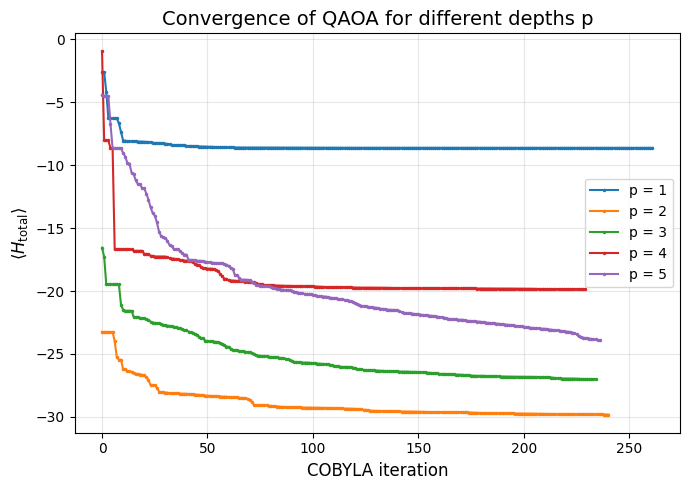

In [14]:
plt.figure(figsize=(7, 5))   # matches approximation ratio plot dimensions
for p, hist in convergence.items():
    plt.plot(hist, marker='.', markersize=3, linewidth=1.5, label=f'p = {p}')
plt.xlabel("COBYLA iteration", fontsize=12)
plt.ylabel(r"$\langle H_{\text{total}} \rangle$", fontsize=12)
plt.title("Convergence of QAOA for different depths p", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("convergence_all_p.tiff", dpi=600, bbox_inches='tight')
plt.show()


=== Optimal QAOA depth = 5 ===
Expected cut = 45.8776  |  Approximation ratio = 0.7176


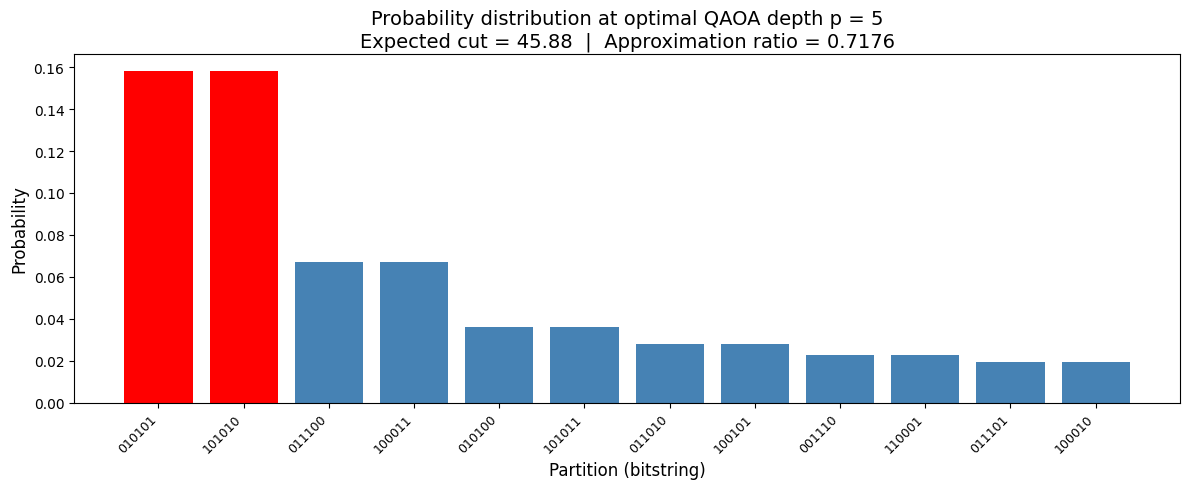

In [11]:
# ============================================================
# FIND OPTIMAL DEPTH (highest expected cut)
# ============================================================
optimal_p_idx = np.argmax(expected_cuts)   # index of best p
optimal_p = p_vals[optimal_p_idx]
best_expected_cut = expected_cuts[optimal_p_idx]
best_ratio = approx_ratios[optimal_p_idx]

print(f"\n=== Optimal QAOA depth = {optimal_p} ===")
print(f"Expected cut = {best_expected_cut:.4f}  |  Approximation ratio = {best_ratio:.4f}")

# ============================================================
# RETRIEVE PROBABILITY DISTRIBUTION FOR OPTIMAL p
# ============================================================
# Recompute probabilities for the optimal p (or retrieve from stored dict)
ansatz_opt = QAOAAnsatz(H_total, reps=optimal_p)
final_circ_opt = ansatz_opt.assign_parameters(best_params[optimal_p])
sv_opt = Statevector(final_circ_opt)
probs_opt = {format(i, f'0{n}b'): np.abs(sv_opt[i])**2 for i in range(2**n)}

# Sort and take top states (e.g., top 12)
sorted_probs_opt = sorted(probs_opt.items(), key=lambda x: x[1], reverse=True)[:12]
top_bitstrings = [bs for bs, _ in sorted_probs_opt]
top_probabilities = [p for _, p in sorted_probs_opt]

# Find the maximum probability bar to highlight
max_prob_val = max(top_probabilities)
colors = ['red' if val == max_prob_val else 'steelblue' for val in top_probabilities]

# ============================================================
# PLOT PROBABILITY DISTRIBUTION FOR OPTIMAL DEPTH
# ============================================================
plt.figure(figsize=(12,5))
bars = plt.bar(range(len(top_bitstrings)), top_probabilities, color=colors)
plt.xticks(range(len(top_bitstrings)), top_bitstrings, rotation=45, ha='right', fontsize=9)
plt.xlabel("Partition (bitstring)", fontsize=12)
plt.ylabel("Probability", fontsize=12)
plt.title(f"Probability distribution at optimal QAOA depth p = {optimal_p}\n"
          f"Expected cut = {best_expected_cut:.2f}  |  Approximation ratio = {best_ratio:.4f}",
          fontsize=14)
plt.tight_layout()
plt.savefig(f"optimal_distribution_p{optimal_p}.tiff", format='tiff', dpi=600, bbox_inches='tight')
plt.show()

In [13]:
import matplotlib.image as mpimg
img = mpimg.imread("approximation_ratio_vs_p.tiff")
print(img.shape)  # gives (height, width, channels)

(3000, 4200, 4)


Using stored parameters for p = 2


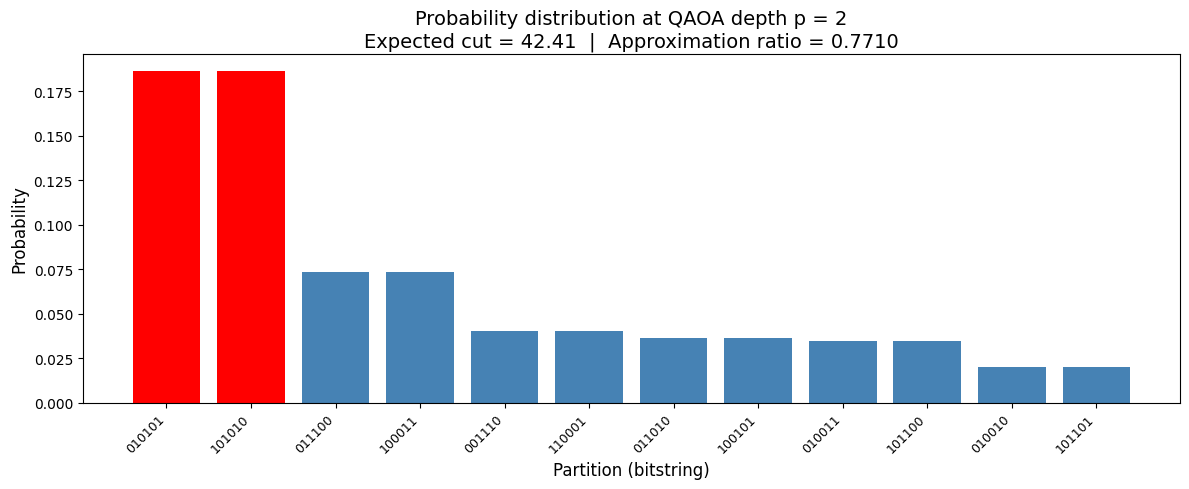

In [15]:
# ============================================================
# PLOT PROBABILITY DISTRIBUTION FOR USER-SPECIFIED p
# ============================================================
def plot_distribution_for_p(p_value):
    """
    Plot probability distribution for a given QAOA depth p_value.
    Uses stored best_params if available, otherwise recomputes.
    """
    # Check if we have stored parameters for this p
    if p_value in best_params:
        params = best_params[p_value]
        print(f"Using stored parameters for p = {p_value}")
    else:
        print(f"No stored parameters for p = {p_value}. Please run optimization first.")
        return

    # Build ansatz and final statevector
    ansatz = QAOAAnsatz(H_total, reps=p_value)
    final_circ = ansatz.assign_parameters(params)
    sv = Statevector(final_circ)
    probs = {format(i, f'0{n}b'): np.abs(sv[i])**2 for i in range(2**n)}

    # Compute expected cut and approximation ratio for this p
    exp_cut = sum(p * cut_value(bs, weights) for bs, p in probs.items())
    ratio = exp_cut / best_cut

    # Sort and take top 12 states
    sorted_probs = sorted(probs.items(), key=lambda x: x[1], reverse=True)[:12]
    top_bitstrings = [bs for bs, _ in sorted_probs]
    top_probabilities = [prob for _, prob in sorted_probs]

    # Highlight the maximum bar
    max_prob = max(top_probabilities)
    colors = ['red' if prob == max_prob else 'steelblue' for prob in top_probabilities]

    # Plot
    plt.figure(figsize=(12,5))
    plt.bar(range(len(top_bitstrings)), top_probabilities, color=colors)
    plt.xticks(range(len(top_bitstrings)), top_bitstrings, rotation=45, ha='right', fontsize=9)
    plt.xlabel("Partition (bitstring)", fontsize=12)
    plt.ylabel("Probability", fontsize=12)
    plt.title(f"Probability distribution at QAOA depth p = {p_value}\n"
              f"Expected cut = {exp_cut:.2f}  |  Approximation ratio = {ratio:.4f}",
              fontsize=14)
    plt.tight_layout()
    plt.savefig(f"distribution_p{p_value}.tiff", format='tiff', dpi=600, bbox_inches='tight')
    plt.show()

# ============================================================
# EXAMPLE: Plot for p = 2
# ============================================================
plot_distribution_for_p(2)

In [3]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from itertools import product
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit.library import QAOAAnsatz

# ============================================================
# FIXED RANDOM SEED & TRAFFIC NETWORK (2x3 grid)
# ============================================================
np.random.seed(42)

rows, cols = 2, 3
n = rows * cols
edge_list = []

# horizontal edges
for r in range(rows):
    for c in range(cols - 1):
        u = r * cols + c
        v = r * cols + (c + 1)
        w = np.random.randint(3, 12)
        edge_list.append((u, v, w))

# vertical edges
for c in range(cols):
    for r in range(rows - 1):
        u = r * cols + c
        v = (r + 1) * cols + c
        w = np.random.randint(3, 12)
        edge_list.append((u, v, w))

weights = np.zeros((n, n))
for u, v, w in edge_list:
    weights[u, v] = w
    weights[v, u] = w

G = nx.Graph()
G.add_weighted_edges_from(edge_list)
pos = {r * cols + c: (c, -r) for r in range(rows) for c in range(cols)}

# ============================================================
# BRUTE FORCE OPTIMAL BALANCED CUT
# ============================================================
def cut_value(bitstring, wmat):
    x = [int(b) for b in bitstring]
    cut = 0.0
    for i in range(n):
        for j in range(i + 1, n):
            if x[i] != x[j]:
                cut += wmat[i, j]
    return cut

best_cut = -1.0
best_partitions = []
for bits in product('01', repeat=n):
    if bits.count('1') == n // 2:
        bs = ''.join(bits)
        cur = cut_value(bs, weights)
        if cur > best_cut:
            best_cut = cur
            best_partitions = [bs]
        elif abs(cur - best_cut) < 1e-9:
            best_partitions.append(bs)

print("\n=== OPTIMAL BALANCED MAXCUT ===")
print(f"Optimal cut value = {best_cut}")
print(f"Example optimal partition: {best_partitions[0]}\n")

# ============================================================
# 1. COST HAMILTONIAN (H_cost = Σ w_ij Z_i Z_j)
# ============================================================
def build_cost_hamiltonian(wmat):
    nq = wmat.shape[0]
    H = SparsePauliOp(['I' * nq], coeffs=[0.0])
    for i in range(nq):
        for j in range(i + 1, nq):
            w = wmat[i, j]
            if w != 0:
                pauli = ['I'] * nq
                pauli[i] = 'Z'
                pauli[j] = 'Z'
                H += SparsePauliOp(''.join(pauli), coeffs=[w])
    return H

H_cost = build_cost_hamiltonian(weights)

# ============================================================
# 2. CONSTRAINT-PRESERVING MIXER HAMILTONIAN
#    H_mixer = Σ_{i<j} (X_i X_j + Y_i Y_j)
# ============================================================
def build_mixer_hamiltonian(nq):
    H = SparsePauliOp(['I' * nq], coeffs=[0.0])
    for i in range(nq):
        for j in range(i + 1, nq):
            pauli_xx = ['I'] * nq
            pauli_xx[i] = 'X'
            pauli_xx[j] = 'X'
            H += SparsePauliOp(''.join(pauli_xx), coeffs=[1.0])
            pauli_yy = ['I'] * nq
            pauli_yy[i] = 'Y'
            pauli_yy[j] = 'Y'
            H += SparsePauliOp(''.join(pauli_yy), coeffs=[1.0])
    return H

H_mixer = build_mixer_hamiltonian(n)

# ============================================================
# 3. INITIAL STATE: uniform superposition over balanced strings
#    (prepared as a QuantumCircuit)
# ============================================================
balanced_states = []
for bits in product('01', repeat=n):
    if bits.count('1') == n // 2:
        balanced_states.append(''.join(bits))

num_balanced = len(balanced_states)
amp = 1.0 / np.sqrt(num_balanced)
init_statevec = np.zeros(2**n, dtype=complex)
for bs in balanced_states:
    idx = int(bs[::-1], 2)   # little-endian
    init_statevec[idx] = amp

init_circuit = QuantumCircuit(n)
init_circuit.initialize(init_statevec, range(n))

# ============================================================
# 4. HELPER FUNCTIONS
# ============================================================
def expected_cut_from_probs(probs, wmat):
    exp = 0.0
    for bs, p in probs.items():
        exp += p * cut_value(bs, wmat)
    return exp

def objective(params, ansatz, H):
    circ = ansatz.assign_parameters(params)
    sv = Statevector(circ)
    return sv.expectation_value(H).real

# store best parameters for warm‑start
best_params_for_p = {}

# ============================================================
# 5. MAIN LOOP OVER DEPTH p = 1..5
# ============================================================
max_p = 5
p_values = []
approx_ratios = []
expected_cuts = []
convergence_histories = {}

for p in range(1, max_p + 1):
    print(f"\n=== QAOA Depth p = {p} (Constraint‑preserving mixer) ===")
    ansatz = QAOAAnsatz(cost_operator=H_cost,
                        mixer_operator=H_mixer,
                        reps=p,
                        initial_state=init_circuit)

    # Warm‑start initial parameters
    if p == 1:
        gammas = np.linspace(0, np.pi/2, 1)
        betas  = np.linspace(0, np.pi, 1)
        init_params = np.array([gammas[0], betas[0]])
        init_params += np.random.normal(0, 0.05, size=2)
    else:
        prev = best_params_for_p[p-1]
        gamma_new = np.random.uniform(0, np.pi/2)
        beta_new  = np.random.uniform(0, np.pi)
        init_params = np.concatenate([prev, [gamma_new, beta_new]])

    # Optimisation with convergence tracking
    history = []

    def callback(xk):
        val = objective(xk, ansatz, H_cost)
        history.append(val)

    result = minimize(
        lambda x: objective(x, ansatz, H_cost),
        init_params,
        method='L-BFGS-B',
        callback=callback,
        options={'maxiter': 200, 'ftol': 1e-6}
    )
    optimal_params = result.x
    best_params_for_p[p] = optimal_params
    convergence_histories[p] = history

    # Final evaluation of expected cut
    final_circ = ansatz.assign_parameters(optimal_params)
    sv = Statevector(final_circ)
    probs = {format(i, f'0{n}b'): np.abs(sv[i])**2 for i in range(2**n)}
    exp_cut = expected_cut_from_probs(probs, weights)
    ratio = exp_cut / best_cut

    p_values.append(p)
    expected_cuts.append(exp_cut)
    approx_ratios.append(ratio)

    print(f"Expected cut = {exp_cut:.4f}  |  Approximation ratio = {ratio:.4f}")

    # --- Plot probability distribution (top 8) ---
    sorted_probs = sorted(probs.items(), key=lambda x: x[1], reverse=True)[:8]
    top_bits = [b for b, _ in sorted_probs]
    top_probs_vals = [pr for _, pr in sorted_probs]
    plt.figure(figsize=(10, 4))
    plt.bar(range(len(top_bits)), top_probs_vals, tick_label=top_bits)
    plt.xlabel("Partition (bitstring)")
    plt.ylabel("Probability")
    plt.title(f"Probability Distribution (p={p})")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"prob_dist_p{p}_constraint_mixer.tiff", format='tiff', dpi=600)
    plt.close()

    # --- Plot convergence of <H_cost> ---
    plt.figure(figsize=(8, 5))
    plt.plot(history, marker='o', markersize=3, linewidth=1)
    plt.xlabel("Iteration (function evaluation)")
    plt.ylabel(r"$\langle H_{\text{cost}} \rangle$")
    plt.title(f"Convergence of QAOA with Constraint‑Preserving Mixer (p={p})")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"convergence_p{p}_constraint_mixer.tiff", format='tiff', dpi=600)
    plt.close()

# ============================================================
# 6. PLOT APPROXIMATION RATIO vs p
# ============================================================
plt.figure(figsize=(7, 5))
plt.plot(p_values, approx_ratios, marker='o', linewidth=2)
plt.xlabel("QAOA Layers (p)")
plt.ylabel("Approximation Ratio")
plt.title("Approximation Ratio vs Depth (Constraint‑Preserving Mixer)")
plt.grid(True)
plt.savefig("approx_ratio_vs_p_constraint_mixer.tiff", format='tiff', dpi=600)
plt.close()

# ============================================================
# 7. BEST PARTITION VISUALISATION (using the deepest p)
# ============================================================
final_ansatz = QAOAAnsatz(cost_operator=H_cost,
                          mixer_operator=H_mixer,
                          reps=max_p,
                          initial_state=init_circuit)
final_ansatz = final_ansatz.assign_parameters(best_params_for_p[max_p])
sv_best = Statevector(final_ansatz)
probs_best = {format(i, f'0{n}b'): np.abs(sv_best[i])**2 for i in range(2**n)}
best_bs = max(probs_best.items(), key=lambda x: x[1])[0]
best_cut_found = cut_value(best_bs, weights)

node_colors = ['lightgreen' if best_bs[i] == '0' else 'salmon' for i in range(n)]
plt.figure(figsize=(6, 4))
nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=700)
edge_labels = {(u, v): w for u, v, w in edge_list}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title(f"Best QAOA Partition (p={max_p})\nCut = {best_cut_found} (optimal {best_cut})")
plt.axis('equal')
plt.savefig("best_partition_constraint_mixer.tiff", format='tiff', dpi=600)
plt.close()

# ============================================================
# 8. SAMPLE CIRCUIT FOR p=2 (fixed drawing)
# ============================================================
qc_sample = QAOAAnsatz(cost_operator=H_cost,
                       mixer_operator=H_mixer,
                       reps=2,
                       initial_state=init_circuit,
                       name="QAOA_constraint")
# Decompose to show the actual gates and draw with matplotlib
qc_decomp = qc_sample.decompose(reps=2)
fig = qc_decomp.draw('mpl', style="clifford", scale=0.7, plot_barriers=False)
fig.savefig("sample_qaoa_circuit_p2_constraint_mixer.tiff", format='tiff', dpi=600, bbox_inches='tight')
plt.close(fig)

# ============================================================
# 9. TRAFFIC NETWORK PLOT (for reference)
# ============================================================
plt.figure(figsize=(6, 4))
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=700)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title("Traffic Road Network (2x3 grid)")
plt.axis('equal')
plt.savefig("traffic_network.tiff", format='tiff', dpi=600)
plt.close()

# ============================================================
# 10. SUMMARY
# ============================================================
print("\n" + "="*60)
print("FINAL RESULTS – CONSTRAINT‑PRESERVING MIXER")
print("="*60)
for i, p in enumerate(p_values):
    print(f"p={p:2d} : Expected Cut = {expected_cuts[i]:6.2f}  |  Approx. Ratio = {approx_ratios[i]:.4f}")
print(f"\nOptimal cut (brute force) = {best_cut:.2f}")
print("All TIFF plots saved successfully.")


=== OPTIMAL BALANCED MAXCUT ===
Optimal cut value = 55.0
Example optimal partition: 010101


=== QAOA Depth p = 1 (Constraint‑preserving mixer) ===
Expected cut = 36.3491  |  Approximation ratio = 0.6609

=== QAOA Depth p = 2 (Constraint‑preserving mixer) ===
Expected cut = 40.4769  |  Approximation ratio = 0.7359

=== QAOA Depth p = 3 (Constraint‑preserving mixer) ===
Expected cut = 52.1273  |  Approximation ratio = 0.9478

=== QAOA Depth p = 4 (Constraint‑preserving mixer) ===
Expected cut = 51.1376  |  Approximation ratio = 0.9298

=== QAOA Depth p = 5 (Constraint‑preserving mixer) ===
Expected cut = 51.8437  |  Approximation ratio = 0.9426

FINAL RESULTS – CONSTRAINT‑PRESERVING MIXER
p= 1 : Expected Cut =  36.35  |  Approx. Ratio = 0.6609
p= 2 : Expected Cut =  40.48  |  Approx. Ratio = 0.7359
p= 3 : Expected Cut =  52.13  |  Approx. Ratio = 0.9478
p= 4 : Expected Cut =  51.14  |  Approx. Ratio = 0.9298
p= 5 : Expected Cut =  51.84  |  Approx. Ratio = 0.9426

Optimal cut (brute fo

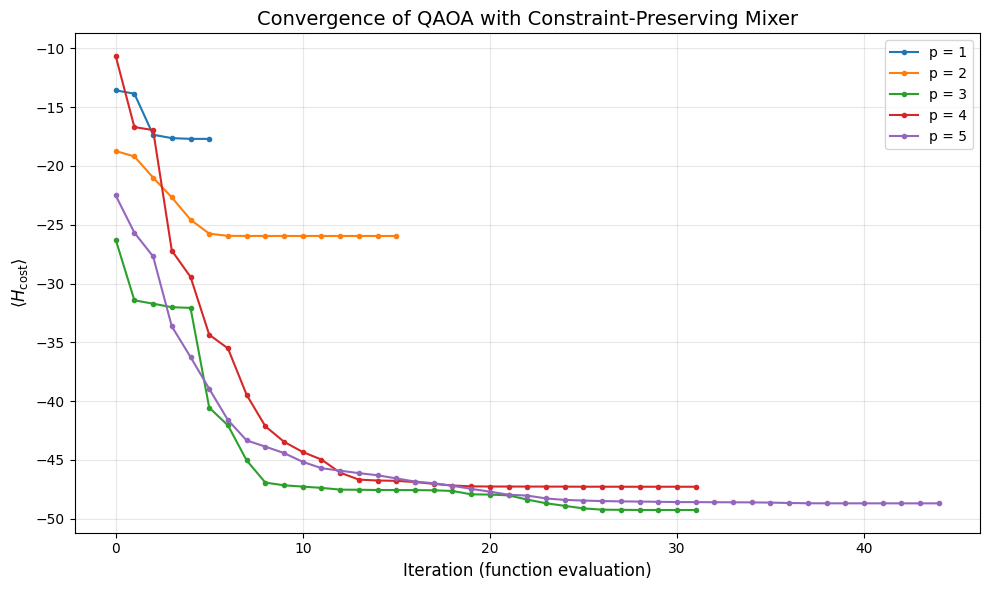

In [4]:
import matplotlib.pyplot as plt

# Assuming convergence_histories is already defined (from the main loop)
plt.figure(figsize=(10, 6))

for p, hist in convergence_histories.items():
    plt.plot(hist, label=f'p = {p}', linewidth=1.5, marker='o', markersize=3)

plt.xlabel('Iteration (function evaluation)', fontsize=12)
plt.ylabel(r'$\langle H_{\text{cost}} \rangle$', fontsize=12)
plt.title('Convergence of QAOA with Constraint‑Preserving Mixer', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("combined_convergence_constraint_mixer.tiff", format='tiff', dpi=600)
plt.show()

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit

# ------------------------------------------------------------
# 1. Initialization and Parameter Definitions
# ------------------------------------------------------------
n = 6                        # 6 qubits (corresponding to the 2x3 grid network)
p = 2                        # Depth (2 alternating layers)

# Variational parameters for gamma (cost) and beta (mixer)
gammas = [0.8, 0.6]
betas = [0.5, 0.4]

# Define the edge connections of your 2x3 grid traffic network
edges = [(0, 1), (1, 2), (0, 3), (1, 4), (2, 5), (3, 4), (4, 5)]

# Create the full quantum circuit
qc = QuantumCircuit(n, name="QAOA_Penalty_Gate_Level")

# ------------------------------------------------------------
# 2. Gate-Level Circuit Construction
# ------------------------------------------------------------

# --- STEP A: Initial State Preparation Layer ---
# Emulating the exact Rz -> Rx -> Rz structure from image_9547bd.png
for qubit in range(n):
    qc.rz(np.pi / 2, qubit)
    qc.rx(np.pi / 2, qubit)
    qc.rz(np.pi / 2, qubit)
qc.barrier()  # Boundary marker for initialization block

# --- STEP B: Iterative Alternating Ansatz Layers ---
for step in range(p):
    gamma = gammas[step]
    beta = betas[step]
    
    # 1. Cost Hamiltonian / Penalty Layer (Gate-Level Decomposition)
    for u, v in edges:
        # Using the correct 'cx' method for CNOT gates
        qc.cx(u, v)
        qc.rz(2 * gamma, v)
        qc.cx(u, v)
    
    qc.barrier() # Separate cost from mixer block
    
    # 2. Mixer Layer Execution
    for qubit in range(n):
        qc.rx(2 * beta, qubit)
        
    qc.barrier() # End of current layer step

# ------------------------------------------------------------
# 3. Draw and Save the Full Diagram
# ------------------------------------------------------------
# 'iqx' style provides the clean blue/crimson gate palette from your image
fig = qc.draw('mpl', style='iqx', scale=0.8, plot_barriers=True)

# Adjust figure dimensions to cleanly layout the unrolled operations
fig.set_size_inches(16, 6)            

# Save the final image in high resolution
fig.savefig("qaoa_blocks_p2.tiff", format='tiff', dpi=600, bbox_inches='tight')
plt.close(fig)

print("Gate-level circuit diagram matching image_9547bd.png successfully saved as 'qaoa_blocks_p2.tiff'!")

P:\Softwares\Qiskit New\qiskit_qaoa_env\Lib\site-packages\qiskit\visualization\circuit\matplotlib.py:269: UserWarning: Style JSON file 'iqx.json' not found in any of these locations: P:\Softwares\Qiskit New\qiskit_qaoa_env\Lib\site-packages\qiskit\visualization\circuit\styles\iqx.json, iqx.json. Will use default style.
  self._style, def_font_ratio = load_style(self._style)


Gate-level circuit diagram matching image_9547bd.png successfully saved as 'qaoa_blocks_p2.tiff'!


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit

# ============================================================
# 1. GRAPH & PARAMETER CONFIGURATION
# ============================================================
rows, cols = 2, 3
n = rows * cols  # 6 qubits

# Extract edge structures
edges = []
for r in range(rows):
    for c in range(cols - 1):
        edges.append((r * cols + c, r * cols + (c + 1)))
for c in range(cols):
    for r in range(rows - 1):
        edges.append((r * cols + c, (r + 1) * cols + c))

# Simulation angles (p=2)
gammas = [0.54, 0.32]
betas = [0.41, 0.22]
lambda_penalty = 2.0  

qc = QuantumCircuit(n, name="Penalty_QAOA")

# ============================================================
# 2. CIRCUIT ASSEMBLING
# ============================================================
# Initial Superposition
for qubit in range(n):
    qc.h(qubit)
qc.barrier()

for step in range(len(gammas)):
    gamma = gammas[step]
    beta = betas[step]
    
    # A. Cost Edge Terms
    for u, v in edges:
        qc.cx(u, v)
        qc.rz(2 * gamma, v)
        qc.cx(u, v)
    qc.barrier()
        
    # B. All-to-All Balance Penalty Terms 
    for i in range(n):
        for j in range(i + 1, n):
            qc.cx(i, j)
            qc.rz(2 * lambda_penalty * gamma, j)
            qc.cx(i, j)
    qc.barrier()
    
    # C. Mixing Layer
    for qubit in range(n):
        qc.rx(2 * beta, qubit)
    qc.barrier()

# ============================================================
# 3. HIGH-QUALITY DESIGN & PLOT FIXES
# ============================================================
# 1. 'scale=0.6' reduces gate font and dimensions to avoid overlapping text.
# 2. 'fold=40' wraps long operational chains cleanly onto new rows.
fig = qc.draw('mpl', style='iqx', scale=0.6, plot_barriers=True, fold=40)

# Adjust figure aspect ratio for stacked row rendering
fig.set_size_inches(14, 10)

# Clear boundary padding adjustments
plt.tight_layout()

# Save publication-grade TIFF
fig.savefig("penalty_qaoa_fixed_circuit.tiff", format='tiff', dpi=600, bbox_inches='tight')
plt.close(fig)

print("Polished gate circuit layout saved successfully as 'penalty_qaoa_fixed_circuit.tiff'!")

Polished gate circuit layout saved successfully as 'penalty_qaoa_fixed_circuit.tiff'!


<Figure size 640x480 with 0 Axes>

In [12]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from itertools import product
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit.library import QAOAAnsatz

# ============================================================
# FIXED RANDOM SEED & TRAFFIC NETWORK (2x3 grid)
# ============================================================
np.random.seed(42)

rows, cols = 2, 3
n = rows * cols
edge_list = []

# horizontal edges
for r in range(rows):
    for c in range(cols - 1):
        u = r * cols + c
        v = r * cols + (c + 1)
        w = np.random.randint(3, 12)
        edge_list.append((u, v, w))

# vertical edges
for c in range(cols):
    for r in range(rows - 1):
        u = r * cols + c
        v = (r + 1) * cols + c
        w = np.random.randint(3, 12)
        edge_list.append((u, v, w))

weights = np.zeros((n, n))
for u, v, w in edge_list:
    weights[u, v] = w
    weights[v, u] = w

G = nx.Graph()
G.add_weighted_edges_from(edge_list)
pos = {r * cols + c: (c, -r) for r in range(rows) for c in range(cols)}

# ============================================================
# 1. BRUTE FORCE OPTIMAL BALANCED CUT (for reference)
# ============================================================
def cut_value(bitstring, wmat):
    x = [int(b) for b in bitstring]
    cut = 0.0
    for i in range(len(wmat)):
        for j in range(i+1, len(wmat)):
            if x[i] != x[j]:
                cut += wmat[i, j]
    return cut

best_cut = -1.0
for bits in product('01', repeat=n):
    if bits.count('1') == n // 2:
        bs = ''.join(bits)
        cur = cut_value(bs, weights)
        if cur > best_cut:
            best_cut = cur

print(f"\nOptimal balanced cut (brute force) = {best_cut}")

# ============================================================
# 2. PENALTY HAMILTONIAN: H = H_cost + λ H_balance
#    H_balance = Σ_{i<j} Z_i Z_j  (encourages equal number of 0/1)
# ============================================================
def build_cost_hamiltonian(wmat):
    """H_cost = Σ w_ij Z_i Z_j (to be minimized -> cut maximized)"""
    nq = wmat.shape[0]
    H = SparsePauliOp(['I'*nq], coeffs=[0.0])
    for i in range(nq):
        for j in range(i+1, nq):
            w = wmat[i, j]
            if w != 0:
                pauli = ['I']*nq
                pauli[i] = 'Z'
                pauli[j] = 'Z'
                H += SparsePauliOp(''.join(pauli), coeffs=[w])
    return H

def build_penalty_hamiltonian(wmat, lambda_penalty):
    nq = wmat.shape[0]
    H = build_cost_hamiltonian(wmat)
    # add penalty term λ Σ_{i<j} Z_i Z_j
    for i in range(nq):
        for j in range(i+1, nq):
            pauli = ['I']*nq
            pauli[i] = 'Z'
            pauli[j] = 'Z'
            H += SparsePauliOp(''.join(pauli), coeffs=[lambda_penalty])
    return H

def find_optimal_lambda():
    """Smallest λ such that all ground states of H_total are balanced (n/2 ones)."""
    candidates = np.linspace(0, 20, 41)
    all_states = [format(i, f'0{n}b') for i in range(2**n)]
    # precompute sum_{i<j} Z_iZ_j for each state
    sum_zz = {}
    for bs in all_states:
        bits = [1 if b=='0' else -1 for b in bs]   # Z|0>=+|0>, Z|1>=-|1>
        total = 0
        for i in range(n):
            for j in range(i+1, n):
                total += 1 if bits[i]==bits[j] else -1
        sum_zz[bs] = total
    for lam in candidates:
        energies = {}
        for bs in all_states:
            cost = 0.0
            for i in range(n):
                for j in range(i+1, n):
                    w = weights[i,j]
                    if w != 0:
                        zz = 1 if bs[i]==bs[j] else -1
                        cost += w * zz
            energy = cost + lam * sum_zz[bs]
            energies[bs] = energy
        min_e = min(energies.values())
        ground_states = [bs for bs, e in energies.items() if abs(e-min_e) < 1e-6]
        if all(bs.count('1') == n//2 for bs in ground_states):
            return lam
    return 20.0

lambda_penalty = find_optimal_lambda()
print(f"Optimal penalty λ = {lambda_penalty:.2f}")
H_penalty = build_penalty_hamiltonian(weights, lambda_penalty)
H_cost_only = build_cost_hamiltonian(weights)

# ============================================================
# 3. HELPER FUNCTIONS FOR QAOA WITH PENALTY
# ============================================================
def objective_penalty(params, ansatz, H):
    circ = ansatz.assign_parameters(params)
    sv = Statevector(circ)
    return sv.expectation_value(H).real

def objective_cost_only(params, ansatz, H_cost):
    circ = ansatz.assign_parameters(params)
    sv = Statevector(circ)
    return sv.expectation_value(H_cost).real

def run_qaoa_penalty(current_weights, current_n, p, lambda_penalty, initial_state=None):
    """Run penalty QAOA on a graph of size current_n (indices 0..current_n-1)."""
    H = build_penalty_hamiltonian(current_weights, lambda_penalty)
    if initial_state is None:
        init_circ = QuantumCircuit(current_n)
        init_circ.h(range(current_n))
    else:
        init_circ = initial_state
    ansatz = QAOAAnsatz(cost_operator=H, mixer_operator=None, reps=p, initial_state=init_circ)
    # heuristic initial parameters
    if p == 1:
        init_params = np.array([0.5, 0.5])   # gamma, beta
    else:
        init_params = np.random.uniform(0, np.pi, 2*p)
    result = minimize(lambda x: objective_penalty(x, ansatz, H), init_params,
                      method='COBYLA', options={'maxiter': 300})
    optimal_params = result.x
    final_circ = ansatz.assign_parameters(optimal_params)
    sv = Statevector(final_circ)
    probs = {format(i, f'0{current_n}b'): np.abs(sv[i])**2 for i in range(2**current_n)}
    # compute expectations of Z_i Z_j for all pairs (used for recursion)
    corr = {}
    for i in range(current_n):
        for j in range(i+1, current_n):
            exp = 0.0
            for bs, prob in probs.items():
                exp += prob * (1 if bs[i]==bs[j] else -1)
            corr[(i,j)] = exp
    return probs, corr

# ============================================================
# 4. RECURSIVE QAOA (penalty-based) – CORRECTED VERSION
# ============================================================
def rqaoa_penalty(weights, n, lambda_penalty, p):
    """
    Recursive QAOA that reduces the graph until 1 qubit remains.
    Returns: (final_cut, best_bitstring, steps)
    """
    curr_weights = weights.copy()
    original_indices = list(range(n))   # maps current index -> original vertex number
    eliminations = []                   # list of (orig_i, orig_j, sign)
    steps = 0

    while len(original_indices) > 1:
        curr_n = len(original_indices)
        print(f"Recursion step {steps}: {curr_n} qubits remaining")
        probs, corr = run_qaoa_penalty(curr_weights, curr_n, p, lambda_penalty)
        # pick pair with largest absolute correlation
        best_pair = max(corr.items(), key=lambda x: abs(x[1]))
        (i, j), corr_val = best_pair
        sign = 1 if corr_val > 0 else -1
        orig_i = original_indices[i]
        orig_j = original_indices[j]
        eliminations.append((orig_i, orig_j, sign))

        # Build reduced weight matrix by eliminating vertex j
        new_size = curr_n - 1
        new_weights = np.zeros((new_size, new_size))
        new_orig_indices = []
        old_to_new = {}
        new_idx = 0
        for k in range(curr_n):
            if k == j: continue
            old_to_new[k] = new_idx
            new_orig_indices.append(original_indices[k])
            new_idx += 1

        # Copy edges not involving j
        for a in range(curr_n):
            if a == j: continue
            for b in range(a+1, curr_n):
                if b == j: continue
                na = old_to_new[a]
                nb = old_to_new[b]
                new_weights[na, nb] = curr_weights[a, b]
                new_weights[nb, na] = curr_weights[a, b]

        # Add contributions from edges (k,i) and (k,j) with substitution Z_j = sign * Z_i
        for k in range(curr_n):
            if k == i or k == j: continue
            w_ki = curr_weights[k, i]
            w_kj = curr_weights[k, j]
            combined = w_ki + sign * w_kj
            na = old_to_new[k]
            nb = old_to_new[i]
            new_weights[na, nb] += combined
            new_weights[nb, na] += combined

        curr_weights = new_weights
        original_indices = new_orig_indices
        steps += 1

    # Only one vertex left: its original index is original_indices[0]
    root = original_indices[0]

    # Reconstruct assignment by processing eliminations in reverse order
    def assign_from_root(root_val):
        assign = {root: root_val}
        for orig_i, orig_j, sgn in reversed(eliminations):
            if orig_i in assign:
                assign[orig_j] = assign[orig_i] if sgn == 1 else 1 - assign[orig_i]
            elif orig_j in assign:
                assign[orig_i] = assign[orig_j] if sgn == 1 else 1 - assign[orig_j]
            else:
                raise RuntimeError(f"Neither {orig_i} nor {orig_j} assigned")
        # Build full bitstring for all original vertices
        bits = ''.join(str(assign.get(i, 0)) for i in range(n))
        return cut_value(bits, weights)

    cut0 = assign_from_root(0)
    cut1 = assign_from_root(1)
    final_cut = max(cut0, cut1)

    # Build the better bitstring
    assign = {root: 0} if cut0 >= cut1 else {root: 1}
    for orig_i, orig_j, sgn in reversed(eliminations):
        if orig_i in assign:
            assign[orig_j] = assign[orig_i] if sgn == 1 else 1 - assign[orig_i]
        else:
            assign[orig_i] = assign[orig_j] if sgn == 1 else 1 - assign[orig_j]
    best_bitstring = ''.join(str(assign[i]) for i in range(n))

    return final_cut, best_bitstring, steps

# ============================================================
# 5. MAIN EXECUTION
# ============================================================
p_values = [1, 2, 3, 4, 5]
recursion_ratios = []
recursion_cuts = []

# --- Part A: Convergence curves for standard penalty QAOA (non-recursive) ---
convergence_histories = {}
for p in p_values:
    print(f"\n--- Running penalty QAOA (p={p}) for convergence trace ---")
    ansatz = QAOAAnsatz(cost_operator=H_penalty, mixer_operator=None, reps=p, initial_state=None)
    init_params = np.random.uniform(0, np.pi, 2*p)
    history = []
    def callback(xk):
        val = objective_cost_only(xk, ansatz, H_cost_only)
        history.append(val)
    minimize(lambda x: objective_penalty(x, ansatz, H_penalty), init_params,
             method='COBYLA', callback=callback, options={'maxiter': 200})
    convergence_histories[p] = history

# --- Part B: Recursive QAOA for each p ---
for p in p_values:
    print(f"\n--- Running RQAOA (p={p}) ---")
    final_cut, best_bs, steps = rqaoa_penalty(weights, n, lambda_penalty, p)
    ratio = final_cut / best_cut
    recursion_cuts.append(final_cut)
    recursion_ratios.append(ratio)
    print(f"p={p}: final cut = {final_cut}, ratio = {ratio:.4f}")

# --- Part C: Probability distribution from a final QAOA run (p=5) ---
print("\n--- Final QAOA on original graph (p=5) for probability distribution ---")
final_ansatz = QAOAAnsatz(cost_operator=H_penalty, mixer_operator=None, reps=5, initial_state=None)
init_params = np.random.uniform(0, np.pi, 10)
result = minimize(lambda x: objective_penalty(x, final_ansatz, H_penalty), init_params,
                  method='COBYLA', options={'maxiter': 300})
opt_params = result.x
final_circ = final_ansatz.assign_parameters(opt_params)
sv = Statevector(final_circ)
probs = {format(i, f'0{n}b'): np.abs(sv[i])**2 for i in range(2**n)}
sorted_probs = sorted(probs.items(), key=lambda x: x[1], reverse=True)[:12]

# ============================================================
# 6. PLOTS (only three)
# ============================================================
# Plot 1: Approximation ratio vs p
plt.figure(figsize=(8,5))
plt.plot(p_values, recursion_ratios, marker='o', linewidth=2)
plt.xlabel("QAOA Depth (p)")
plt.ylabel("Approximation Ratio")
plt.title("RQAOA Performance: Ratio vs Depth")
plt.grid(True)
plt.savefig("r_vs_p_ratio.tiff", dpi=600, bbox_inches='tight')
plt.close()

# Plot 2: Probability distribution (top 12 states)
plt.figure(figsize=(10,5))
top_bits = [b for b,_ in sorted_probs]
top_vals = [v for _,v in sorted_probs]
plt.bar(range(len(top_bits)), top_vals, tick_label=top_bits)
plt.xlabel("Bitstring (partition)")
plt.ylabel("Probability")
plt.title("Final QAOA Probability Distribution (p=5, penalty‑based)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("probability_distribution.tiff", dpi=600, bbox_inches='tight')
plt.close()

# Plot 3: Combined convergence curves for <H_cost>
plt.figure(figsize=(10,6))
for p, hist in convergence_histories.items():
    plt.plot(hist, label=f'p={p}', linewidth=1.5, marker='o', markersize=3)
plt.xlabel("Iteration (function evaluation)")
plt.ylabel(r"$\langle H_{\text{cost}} \rangle$")
plt.title("Convergence of Penalty QAOA for Balanced MaxCut")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("convergence_combined.tiff", dpi=600, bbox_inches='tight')
plt.close()

print("\nAll three plots saved:")
print(" - r_vs_p_ratio.tiff")
print(" - probability_distribution.tiff")
print(" - convergence_combined.tiff")


Optimal balanced cut (brute force) = 55.0
Optimal penalty λ = 0.00

--- Running penalty QAOA (p=1) for convergence trace ---

--- Running penalty QAOA (p=2) for convergence trace ---

--- Running penalty QAOA (p=3) for convergence trace ---

--- Running penalty QAOA (p=4) for convergence trace ---

--- Running penalty QAOA (p=5) for convergence trace ---

--- Running RQAOA (p=1) ---
Recursion step 0: 6 qubits remaining
Recursion step 1: 5 qubits remaining
Recursion step 2: 4 qubits remaining
Recursion step 3: 3 qubits remaining
Recursion step 4: 2 qubits remaining
p=1: final cut = 55.0, ratio = 1.0000

--- Running RQAOA (p=2) ---
Recursion step 0: 6 qubits remaining
Recursion step 1: 5 qubits remaining
Recursion step 2: 4 qubits remaining
Recursion step 3: 3 qubits remaining
Recursion step 4: 2 qubits remaining
p=2: final cut = 55.0, ratio = 1.0000

--- Running RQAOA (p=3) ---
Recursion step 0: 6 qubits remaining
Recursion step 1: 5 qubits remaining
Recursion step 2: 4 qubits remainin

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit

# ============================================================
# 1. GRAPH & PARAMETERS (matching the RQAOA setup)
# ============================================================
rows, cols = 2, 3
n = rows * cols  # 6 qubits

# Edges of the traffic network
edges = []
for r in range(rows):
    for c in range(cols - 1):
        edges.append((r * cols + c, r * cols + (c + 1)))
for c in range(cols):
    for r in range(rows - 1):
        edges.append((r * cols + c, (r + 1) * cols + c))

# Example angles for p=2 (you can replace with your optimal parameters)
gammas = [0.54, 0.32]
betas  = [0.41, 0.22]
lambda_penalty = 2.0   # penalty strength (must be large enough to enforce balance)

# ============================================================
# 2. BUILD THE PENALTY QAOA CIRCUIT (used in RQAOA)
# ============================================================
qc = QuantumCircuit(n, name="Penalty_QAOA_RQAOA")

# Initial superposition
for qubit in range(n):
    qc.h(qubit)
qc.barrier()

for step in range(len(gammas)):
    gamma = gammas[step]
    beta  = betas[step]
    
    # ---- Cost Hamiltonian (edges of the current graph) ----
    for u, v in edges:
        qc.cx(u, v)
        qc.rz(2 * gamma, v)      # exp(-i γ w_uv Z_u Z_v) with w_uv = 1 here (unweighted)
        qc.cx(u, v)
    qc.barrier()
    
    # ---- Balance penalty (all‑to‑all Z_i Z_j) ----
    for i in range(n):
        for j in range(i + 1, n):
            qc.cx(i, j)
            qc.rz(2 * lambda_penalty * gamma, j)
            qc.cx(i, j)
    qc.barrier()
    
    # ---- Mixer (standard X rotations) ----
    for qubit in range(n):
        qc.rx(2 * beta, qubit)
    qc.barrier()

# ============================================================
# 3. DRAW AND SAVE THE CIRCUIT
# ============================================================
fig = qc.draw('mpl', style='iqx', scale=0.6, plot_barriers=True, fold=40)
fig.set_size_inches(14, 10)
plt.tight_layout()
fig.savefig("penalty_rqaoa_circuit.tiff", format='tiff', dpi=600, bbox_inches='tight')
plt.close(fig)

print("Circuit diagram saved as 'penalty_rqaoa_circuit.tiff'")

P:\Softwares\Qiskit New\qiskit_qaoa_env\Lib\site-packages\qiskit\visualization\circuit\matplotlib.py:269: UserWarning: Style JSON file 'iqx.json' not found in any of these locations: P:\Softwares\Qiskit New\qiskit_qaoa_env\Lib\site-packages\qiskit\visualization\circuit\styles\iqx.json, iqx.json. Will use default style.
  self._style, def_font_ratio = load_style(self._style)


Circuit diagram saved as 'penalty_rqaoa_circuit.tiff'


<Figure size 640x480 with 0 Axes>